# MMJL Capture and Notebook-State Regression Test

**1. Markdown cell — test purpose and execution order**

This notebook tests:

1. repository-root discovery from anywhere inside the repository
2. `src/` import setup
3. MMJL utility imports
4. Jupyter magic registration
5. literal Markdown and HTML logging
6. `%%jupy_capture`
7. the `%%jupy_tee` alias
8. failed notebook-state execution in visible order:
   `A -> B -> C`
9. successful recovery by moving backward:
   `B -> A`
10. stdout, exception, rich-display, and Matplotlib capture
11. `%jupy_file`
12. manifest inspection and validation
13. Markdown and HTML timeline generation
14. the Python analogs of `tree`, `wc -l`, and `cat`

The notebook-state dependency graph is:

```text
C creates numbers
B consumes numbers and creates squared_numbers
A consumes numbers and squared_numbers, computes a mean, and plots
```

The cells are displayed as:

```text
A
B
C
B again
A again
```

Therefore the first A and B should fail, C should succeed, and the
subsequent B and A should succeed.

---

**Looking further**:

Here is the complete notebook sequence. The intended execution order is the notebook's ordinary top-to-bottom order, with the exception of the A → B → C → B → A example

---

**Let's go!!!**<br/><br/>

In [1]:
## 2. Code cell 01 — locate the repository root and configure `sys.path`
import importlib
import os
import sys
import pathlib

starting_dir = pathlib.Path.cwd().resolve()
repo_root = None
src_path = None
package_path = None

for candidate_path in [starting_dir, *starting_dir.parents]:
    package_path = (
        candidate_path
        / "src"
        / "multimodal_jupy_logger"
    )

    if package_path.is_dir():
        repo_root = candidate_path
        break
    ##endof:  if package_path.is_dir()
##endof:  for candidate_path in [...]

if repo_root is None:
    raise RuntimeError(
        "Could not find a repository root containing "
        "src/multimodal_jupy_logger."
    )
##endof:  if repo_root is None

src_path = repo_root / "src"

os.chdir(repo_root)

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
##endof:  if str(src_path) not in sys.path

importlib.invalidate_caches()

print("starting_dir:", starting_dir)
print("repo_root:", repo_root)
print("src_path:", src_path)
print("current working directory:", pathlib.Path.cwd())
print("Python executable:", sys.executable)

starting_dir: C:\David\my_repos_dwb\multimodal-jupy-logger\examples
repo_root: C:\David\my_repos_dwb\multimodal-jupy-logger
src_path: C:\David\my_repos_dwb\multimodal-jupy-logger\src
current working directory: C:\David\my_repos_dwb\multimodal-jupy-logger
Python executable: C:\David\my_repos_dwb\multimodal-jupy-logger\.venv_test_mmjl\Scripts\python.exe


In [2]:
## 3. Code cell 02 — import MMJL and the path-display utilities
from multimodal_jupy_logger import (
    MultimodalJupyLogger,
    jupy_logger_register,
    register_jupy_logger,
)

from multimodal_jupy_logger.utils import (
    count_lines,
    path_display,
    print_file,
    tree,
)

from multimodal_jupy_logger.utils import path_display as dpypd

print("MMJL imports succeeded.")
print("path_display module:", dpypd)

MMJL imports succeeded.
path_display module: <module 'multimodal_jupy_logger.utils.path_display' from 'C:\\David\\my_repos_dwb\\multimodal-jupy-logger\\src\\multimodal_jupy_logger\\utils\\path_display.py'>


In [3]:
## 4. Code cell 03 — prove both utility import styles work

print("Directly imported function:")
print("  tree:", tree)

print("\nModule-namespace functions:")
print("  dpypd.tree:", dpypd.tree)
print("  dpypd.count_lines:", dpypd.count_lines)
print("  dpypd.print_file:", dpypd.print_file)

print("\nDirect and module attributes refer to the same functions:")
print("  tree is dpypd.tree:", tree is dpypd.tree)
print(
    "  count_lines is dpypd.count_lines:",
    count_lines is dpypd.count_lines,
)
print(
    "  print_file is dpypd.print_file:",
    print_file is dpypd.print_file,
)

Directly imported function:
  tree: <function tree at 0x0000022D50766A70>

Module-namespace functions:
  dpypd.tree: <function tree at 0x0000022D50766A70>
  dpypd.count_lines: <function count_lines at 0x0000022D50766B00>
  dpypd.print_file: <function print_file at 0x0000022D50766B90>

Direct and module attributes refer to the same functions:
  tree is dpypd.tree: True
  count_lines is dpypd.count_lines: True
  print_file is dpypd.print_file: True


In [4]:
## 5. Code cell 04 — show the relevant repository tree

dpypd.tree(
    this_dir=repo_root,
    dirs_to_exclude=[
        ".git",
        "__pycache__",
        ".venv",
        ".venv_test_mmjl",
        ".ipynb_checkpoints",
    ],
    files_to_exclude=[
        ".pyc",
    ],
)

+ C:\David\my_repos_dwb\multimodal-jupy-logger
    + .gitattributes
    + .gitignore
    + assets/
        + img/
    + docs/
        + context_documents/
        + dev_notes/
            + first_mmjl_smoke_test_2026-06-14.md
            + git_changing_executed_filename_learning_2026-06-17.md
            + jupyter_cell_magic_first_line_learning_2026-06-17.md
            + mmjl_capture_and_state_testing_-_PLAN_2026-06-16.md
            + template_both_better.py
            + template_count_lines.py
            + template_print_file.py
    + examples/
        + complete_pre_jupyter_lab_powershell_io_2026-06-14T152800-0400.log
        + mmjl_capture_and_state_smoke_test.ipynb
        + mmjl_first_smoke_test.ipynb
        + test_setup_and_start.md
    + LICENSE
    + README.md
    + reproducibility_win_init__requirements.txt
    + requirements-ml.txt
    + requirements.txt
    + src/
        + multimodal_jupy_logger/
            + __init__.py
            + logger.py
            + magics.py

For:  **6**

Run this after restarting the kernel and loading the updated files. 
(If you've run the last cells, this is almost certainly done.)

```python
register_jupy_logger()
```

Expected registration text includes:

```text
%%jupy_log
%%jupy_capture
%%jupy_tee
```

In [5]:
## 6. Code cell 05 — register the magics

register_jupy_logger()

[DONE] Registered: %jupy_save, %jupy_file, %%jupy_log, %%jupy_capture, %%jupy_tee, %jupy_markdown, %jupy_html, %jupy_inspect, %jupy_validate


In [6]:
## 7. Code cell 06 — verify that the magics exist

ipython_shell = get_ipython()

magic_names = [
    "jupy_save",
    "jupy_file",
    "jupy_log",
    "jupy_capture",
    "jupy_tee",
    "jupy_markdown",
    "jupy_html",
    "jupy_inspect",
    "jupy_validate",
]

for magic_name in magic_names:
    line_magic = ipython_shell.find_line_magic(magic_name)
    cell_magic = ipython_shell.find_cell_magic(magic_name)

    print(
        f"{magic_name:16s}",
        f"line={line_magic is not None}",
        f"cell={cell_magic is not None}",
    )
##endof:  for magic_name in magic_names

jupy_save        line=True cell=False
jupy_file        line=True cell=False
jupy_log         line=False cell=True
jupy_capture     line=False cell=True
jupy_tee         line=False cell=True
jupy_markdown    line=True cell=False
jupy_html        line=True cell=False
jupy_inspect     line=True cell=False
jupy_validate    line=True cell=False


**8. Markdown cell — notebook-native hidden-text control**

This cell tests Jupyter’s own Markdown rendering independently of MMJL.

```markdown
<strong>Notebook-native `<details>` control</strong>

<details>
<summary>Click the arrow to reveal the notebook-native text</summary>

This text lives directly in a Jupyter Markdown cell.

If clicking the arrow reveals this paragraph, the notebook frontend is
rendering the HTML element correctly.

</details>
```

---

_DWB Note: I think we want to test the following:_

<strong>Notebook-native `<details>` control</strong>

<details>
<summary>Click the arrow to reveal the notebook-native text</summary>

This text lives directly in a Jupyter Markdown cell.

If clicking the arrow reveals this paragraph, the notebook frontend is
rendering the HTML element correctly.

</details>

<br/><hr/>

For **9** (`Code cell 07 — log the original Markdown regression case`)

This preserves the original test: raw `<details>` HTML stored with the
`text/markdown` MIME type.

In [7]:
%%jupy_log --label details-summary-markdown-regression --mime text/markdown
<details>
<summary>Click the arrow to reveal logged Markdown text</summary>

This content was logged as `text/markdown`.

The regression question is whether exported timelines preserve this as
renderable Markdown/HTML or incorrectly turn it into escaped or fenced
source text.

</details>

## 9 Code cell 07 — log the original Markdown regression case

[DONE] Logged text: C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md


WindowsPath('C:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log/artifacts/000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md')

For **10** (`Code cell 08 — log an HTML control version`)

This distinguishes a general `<details>` failure from a Markdown-MIME
rendering-policy failure.

With the current timeline builder, the expected distinction is:

* `text/html`: should render as a collapsible block in the HTML timeline
* `text/markdown`: currently may appear as escaped/fenced source

That would identify a timeline-rendering issue, not a capture failure.

In [8]:
%%jupy_log --label details-summary-html-control --mime text/html
<details>
<summary>Click the arrow to reveal logged HTML text</summary>

<p>
This content was logged as <code>text/html</code>. It should be inserted
as HTML in the generated HTML timeline.
</p>

</details>

## 10. Code cell 08 — log an HTML control version

[DONE] Logged text: C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html


WindowsPath('C:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log/artifacts/000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html')

In [9]:
# Code cell 09

dpypd.tree(
    this_dir=repo_root,
    dirs_to_exclude=[
        ".git",
        "__pycache__",
        ".venv",
        ".venv_test_mmjl",
        ".ipynb_checkpoints",
    ],
    files_to_exclude=[
        ".pyc",
    ],
)

+ C:\David\my_repos_dwb\multimodal-jupy-logger
    + .gitattributes
    + .gitignore
    + assets/
        + img/
    + docs/
        + context_documents/
        + dev_notes/
            + first_mmjl_smoke_test_2026-06-14.md
            + git_changing_executed_filename_learning_2026-06-17.md
            + jupyter_cell_magic_first_line_learning_2026-06-17.md
            + mmjl_capture_and_state_testing_-_PLAN_2026-06-16.md
            + template_both_better.py
            + template_count_lines.py
            + template_print_file.py
    + examples/
        + complete_pre_jupyter_lab_powershell_io_2026-06-14T152800-0400.log
        + mmjl_capture_and_state_smoke_test.ipynb
        + mmjl_first_smoke_test.ipynb
        + test_setup_and_start.md
    + jupy_log/
        + artifacts/
            + 000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
            + 000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
        + mani

In [10]:
## Code cell 10

dpypd.tree("C:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log")

+ C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
        + 000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
    + manifest.tsv


In [12]:
##  Code cell 11 — ANYTHING NEW? (reusable count_lines or print_file)
##+      MAKE SURE TO MATCH THE FILENAME WITH TREE OUTPUT
print("##############################################################")
print(); print(
    "----------------------------------------------------------\n" + \
    "___File contents for___\n" + \
    "   'jupy_log/artifacts/\n" + \
    "    000001_1781783733033_2026-06-18T075533033-0400_\n" + \
    "    details-summary-markdown-regression.md'___\n" + \
    "----------------------------------------------------------"
); dpypd.print_file(
    (
        "C:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log/"
        "artifacts/"
        "000001_1781783733033_2026-06-18T075533033-0400_"
        "details-summary-markdown-regression.md"
    )
); print("----------------------------------------------------------")
print("=========================================================="); print()
print("==========================================================")
print(
    "----------------------------------------------------------\n" + \
    "___File contents for___\n" + \
    "   'jupy_log/artifacts/\n" + \
    "    000002_1781783736601_2026-06-18T075536601-0400_\n" + \
    "    details-summary-html-control.html'___\n" + \
    "----------------------------------------------------------"
); dpypd.print_file(
    (
        "C:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log/"
        "artifacts/"
        "000002_1781783736601_2026-06-18T075536601-0400_"
        "details-summary-html-control.html"
    )
); print("----------------------------------------------------------")
print("=========================================================="); print()
print("==========================================================")
print(
    "----------------------------------------------------------\n" + \
    "___File contents for___\n" + \
    "   'jupy_log/manifest.tsv\n" + \
    "----------------------------------------------------------"
); dpypd.print_file(
    (
        "C:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log/"
        "manifest.tsv"
    )
); print("----------------------------------------------------------")
print(); print()
print("##############################################################")

##############################################################

----------------------------------------------------------
___File contents for___
   'jupy_log/artifacts/
    000001_1781783733033_2026-06-18T075533033-0400_
    details-summary-markdown-regression.md'___
----------------------------------------------------------
<details>
<summary>Click the arrow to reveal logged Markdown text</summary>

This content was logged as `text/markdown`.

The regression question is whether exported timelines preserve this as
renderable Markdown/HTML or incorrectly turn it into escaped or fenced
source text.

</details>

## 9 Code cell 07 — log the original Markdown regression case
----------------------------------------------------------

----------------------------------------------------------
___File contents for___
   'jupy_log/artifacts/
    000002_1781783736601_2026-06-18T075536601-0400_
    details-summary-html-control.html'___
----------------------------------------------------------

**New stuff after Code cell 11**

<details>
<summary>Click the arrow to see the file contents. Note internal HTML was escaped.</summary>

<pre>
##############################################################

----------------------------------------------------------
___File contents for___
   'jupy_log/artifacts/
    000001_1781783733033_2026-06-18T075533033-0400_
    details-summary-markdown-regression.md'___
----------------------------------------------------------
&lt;details&gt;
&lt;summary>Click the arrow to reveal logged Markdown text&gt;/summary&gt;

This content was logged as `text/markdown`.

The regression question is whether exported timelines preserve this as
renderable Markdown/HTML or incorrectly turn it into escaped or fenced
source text.

&lt;/details&gt;

## 9 Code cell 07 — log the original Markdown regression case
----------------------------------------------------------
==========================================================

==========================================================
----------------------------------------------------------
___File contents for___
   'jupy_log/artifacts/
    000002_1781783736601_2026-06-18T075536601-0400_
    details-summary-html-control.html'___
----------------------------------------------------------
&lt;details&gt;
&lt;summary&gt;Click the arrow to reveal logged HTML text&lt;/summary&gt;

&lt;p&gt;
This content was logged as <code>text/html</code>. It should be inserted
as HTML in the generated HTML timeline.
&lt;/p&gt;

&lt;/details&gt;

## 10. Code cell 08 — log an HTML control version
----------------------------------------------------------
==========================================================

==========================================================
----------------------------------------------------------
___File contents for___
   'jupy_log/manifest.tsv
----------------------------------------------------------
artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
000001		1781783733033_2026-06-18T075533033-0400	text	text/markdown	literal	details-summary-markdown-regression	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
000002		1781783736601_2026-06-18T075536601-0400	html	text/html	literal	details-summary-html-control	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
----------------------------------------------------------


##############################################################
</pre>

</details>

<hr/>

**Making this easier for next time**

```python
## Code cell N-1

dpypd.tree("C:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log")
```

Have a look at 

```text
../docs/dev_notes/template*.py
```

or look at, and possibly copy and paste, the following

```python
##  Code cell N, ANYTHING NEW?
##+      MAKE SURE TO MATCH THE FILENAME WITH TREE OUTPUT

hashes="#"*63; dashes="-"*59; equalses="="*59; print_start="___Fil" + \
"e contents for___\n   'jupy_log/"; count_start="___File line coun" + \
"t for___\n   'jupy_log/"; full_stem_path="C:/David/my_repos_dwb/m" + \
"ultimodal-jupy-logger/jupy_log/";      either_end=f"'___\n{dashes}\n";
print(f"{hashes}"); print(); print(f"{dashes}\n");

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
path_second_part="";path_third_part="";
#a.1  #the_right_start = print_start;
#a.2  #the_right_start = count_start;
# b   #art_str="artifacts/";
short_pth="";
# c.1#dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="";
path_third_part ="";
# c.2#dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
#d.1  #the_right_end=contd_bigger_end;
#d.2  #the_right_end=ended_bigger_end;
print(the_right_end)

##
```

_**`Instructions for the above`**_
- if (you want to count):
  - \# in general, if you don't know, count lines first
  - uncomment `#a.2  #` 
- else: (here if (you want to print))
  - \# often good to do once you've counted lines
  - uncomment `#a.1  #`
- \##endof:  if/else {count/print}
- \#
- uncomment `# c.1#` \# might be times when it doesn't get used, but none I know of yet
- \#
- if (file not in `artifacts/` subdirectory):
  - put whatever path comes after `jupy_log` until your goal filename extension into `short_pth`
  - **do not** later uncomment `# c.2` \# I messed up this part during a lot of this run, no biggie
  - \##endof:  if (file not in artifacts subdirectory)
- else: \# (here if (file in artifacts subdirectory))
  - `#  Note, if you need to refactor, that ``dpath`` is 'display path',`
  - `#+ ``path_pass``: passed to ``print_file`` or ``count_lines`` `
  - `#+ so don't give ``\n`` to ``path_pass`` (please don't put ``\n`` in fnames)`
  - put parts of the file path string _after `artifacts/` into two blank strings...
    - first (and maybe only) part of what's left into `path_second_part`
      - this is usually all the numeric, timestamp etc. information and trailing underscore
    - second (if needed) part, what's left, int `path_third_part`
      - this is usually the alpha-and-underscores part to the extension
        - (don't double the trailing underscore)
    - if (things are still too long):
      - split the rest of the string into other parts and refactor code
      - (add string names into `dpath_post_jupy_log`, also int `path_pass`)
    - \##endof:  if (things are still too long)
  - uncomment `# c.2#`
- \##endof:  if/else {file (is not|is) in `artifacts/` subdirectory}
- \#
- if (this is the last file you're displaying or counting):
  - uncomment `#d.2  #`
- else: \# (here if (you want to display or count another file))
  - uncomment `#d.1  #`
- \##endof: if/else {(last file)|(more files)}

_**`End of Instructions`**_

In [13]:
## Code cell 12, repeated Code cell 11 (?)
if True: pass

In [ ]:
## Code cell 13, repeated Code cell 11 (?)
if True: pass

In [14]:
##  Code cell 14 — ANYTHING NEW? (reusable count_lines or print_file)
##+      MAKE SURE TO MATCH THE FILENAME WITH TREE OUTPUT

##  Once again, this seems a repeat of Code cell 11, but it's a
##+ good place to test it.

hashes="#"*63; dashes="-"*59; equalses="="*59; print_start="___Fil" + \
"e contents for___\n   'jupy_log/"; count_start="___File line coun" + \
"t for___\n   'jupy_log/"; full_stem_path="C:/David/my_repos_dwb/m" + \
"ultimodal-jupy-logger/jupy_log/";      either_end=f"'___\n{dashes}\n";
print(f"{hashes}"); print(); print(f"{dashes}\n");

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
path_second_part="";path_third_part="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000001_1781783733033_2026-06-18T075533033-0400_";
path_third_part ="details-summary-markdown-regression.md";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
the_right_end=contd_bigger_end;
#d.2  #the_right_end=ended_bigger_end;
print(the_right_end)

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
path_second_part="";path_third_part="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000002_1781783736601_2026-06-18T075536601-0400_";
path_third_part ="details-summary-html-control.html";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}";
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
#d.1  #the_right_end=contd_bigger_end;
the_right_end=ended_bigger_end;
print(the_right_end)

###############################################################

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000001_1781783733033_2026-06-18T075533033-0400_
details-summary-markdown-regression.md'___
-----------------------------------------------------------

<details>
<summary>Click the arrow to reveal logged Markdown text</summary>

This content was logged as `text/markdown`.

The regression question is whether exported timelines preserve this as
renderable Markdown/HTML or incorrectly turn it into escaped or fenced
source text.

</details>

## 9 Code cell 07 — log the original Markdown regression case
-----------------------------------------------------------

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000002_1781783736601_2026-06-18T075536601-0400_
details-summary-html-control.html'___
-----------------------------------------------------------

<deta

**New stuff after Code cell 14**

<details>
<summary>Click the arrow to see the file contents. Note internal HTML was escaped.</summary>

<pre>
###############################################################

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000001_1781783733033_2026-06-18T075533033-0400_
details-summary-markdown-regression.md'___
-----------------------------------------------------------

&lt;details&gt;
&lt;summary&gt;Click the arrow to reveal logged Markdown text&lt;/summary&gt;

This content was logged as `text/markdown`.

The regression question is whether exported timelines preserve this as
renderable Markdown/HTML or incorrectly turn it into escaped or fenced
source text.

&lt;/details&gt;

## 9 Code cell 07 — log the original Markdown regression case
-----------------------------------------------------------
===========================================================

===========================================================
-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000002_1781783736601_2026-06-18T075536601-0400_
details-summary-html-control.html'___
-----------------------------------------------------------

&lt;details&gt;
&lt;summary&gt;Click the arrow to reveal logged HTML text&lt;/summary&gt;

&lt;p&gt;
This content was logged as &lt;code&gt;text/html&lt;/code&gt;. It should be inserted
as HTML in the generated HTML timeline.
&lt;/p&gt;

&lt;/details&gt;

## 10. Code cell 08 — log an HTML control version
-----------------------------------------------------------


###############################################################
</pre>

</details>

<hr/>

For **11** (`Code cell 15 — basic ``%%jupy_capture`` smoke test`)

Expected capture roles include:

```text
input
stdout
display
```

The final expression `5` may be represented through one or more MIME
items, commonly including `text/plain`.

In [15]:
%%jupy_capture --label capture-basic
message = "This stdout should be displayed and logged."
print(message)

## 11. Code cell 15 — basic `%%jupy_capture` smoke test

This stdout should be displayed and logged.
[DONE] Capture 000001: logged 2 artifact(s).


<ExecutionResult object at 22d530dccd0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 22d530dcf40, raw_cell="message = "This stdout should be displayed and log.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

In [16]:
## Code cell 16

dpypd.tree("C:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log")

+ C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
        + 000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
        + 000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
        + 000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
    + manifest.tsv


In [17]:
##  Code cell 17, ANYTHING NEW?
##+      MAKE SURE TO MATCH THE FILENAME WITH TREE OUTPUT

hashes="#"*63; dashes="-"*59; equalses="="*59; print_start="___Fil" + \
"e contents for___\n   'jupy_log/"; count_start="___File line coun" + \
"t for___\n   'jupy_log/"; full_stem_path="C:/David/my_repos_dwb/m" + \
"ultimodal-jupy-logger/jupy_log/";      either_end=f"'___\n{dashes}\n";
print(f"{hashes}"); print(); print(f"{dashes}\n");

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000003_1781784186098_2026-06-18T080306098-0400_";
path_third_part ="capture-basic-input.py";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
the_right_end=contd_bigger_end;
#d.2  #the_right_end=ended_bigger_end;
print(the_right_end)

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000004_1781784186145_2026-06-18T080306145-0400_";
path_third_part ="capture-basic-stdout.txt";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
the_right_end=contd_bigger_end;
#d.2  #the_right_end=ended_bigger_end;
print(the_right_end)

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
# b   #art_str="artifacts/";
short_pth="manifest.tsv";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="";
path_third_part ="";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
#d.1  #the_right_end=contd_bigger_end;
the_right_end=ended_bigger_end;
print(the_right_end)

###############################################################

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000003_1781784186098_2026-06-18T080306098-0400_
capture-basic-input.py'___
-----------------------------------------------------------

message = "This stdout should be displayed and logged."
print(message)

## 11. Code cell 15 — basic `%%jupy_capture` smoke test
-----------------------------------------------------------

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000004_1781784186145_2026-06-18T080306145-0400_
capture-basic-stdout.txt'___
-----------------------------------------------------------

This stdout should be displayed and logged.
-----------------------------------------------------------

-----------------------------------------------------------

___File contents for___
   'jupy_log/manifest.tsv

'___
--------------------------------

**New stuff after Code cell 17**

<details>
<summary>Click the arrow to see the file contents. Note internal HTML was escaped.</summary>

<pre>
###############################################################

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000003_1781784186098_2026-06-18T080306098-0400_
capture-basic-input.py'___
-----------------------------------------------------------

message = "This stdout should be displayed and logged."
print(message)

## 11. Code cell 15 — basic `%%jupy_capture` smoke test
-----------------------------------------------------------
===========================================================

===========================================================
-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000004_1781784186145_2026-06-18T080306145-0400_
capture-basic-stdout.txt'___
-----------------------------------------------------------

This stdout should be displayed and logged.
-----------------------------------------------------------
===========================================================

===========================================================
-----------------------------------------------------------

___File contents for___
   'jupy_log/manifest.tsv

'___
-----------------------------------------------------------

artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
000001		1781783733033_2026-06-18T075533033-0400	text	text/markdown	literal	details-summary-markdown-regression	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
000002		1781783736601_2026-06-18T075536601-0400	html	text/html	literal	details-summary-html-control	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
000003	000001	1781784186098_2026-06-18T080306098-0400	text	text/x-python	input	capture-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
000004	000001	1781784186145_2026-06-18T080306145-0400	text	text/plain	stdout	capture-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
-----------------------------------------------------------


###############################################################
</pre>

</details>

<hr/>

For **12** (`Code cell 18 — basic ``%%jupy_tee`` alias test`)

Not really anything to comment about, but here it comes.

In [18]:
%%jupy_tee --label tee-basic
tee_message = "The %%jupy_tee alias executed this cell."
print(tee_message)

tee_message.upper()

## 12. Code cell 18 — basic `%%jupy_tee` alias test

The %%jupy_tee alias executed this cell.


'THE %%JUPY_TEE ALIAS EXECUTED THIS CELL.'

[DONE] Capture 000002: logged 3 artifact(s).


<ExecutionResult object at 22d531a63b0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 22d531a6b00, raw_cell="tee_message = "The %%jupy_tee alias executed this .." store_history=False silent=False shell_futures=True cell_id=None> result=None>

In [19]:
## Code cell 19

dpypd.tree("C:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log")

+ C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
        + 000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
        + 000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
        + 000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
        + 000005_1781784487807_2026-06-18T080807807-0400_tee-basic-input.py
        + 000006_1781784487817_2026-06-18T080807817-0400_tee-basic-stdout.txt
        + 000007_1781784487825_2026-06-18T080807825-0400_tee-basic-display-01-01-text.txt
    + manifest.tsv


In [20]:
##  Code cell 20, ANYTHING NEW?
##+      MAKE SURE TO MATCH THE FILENAME WITH TREE OUTPUT

hashes="#"*63; dashes="-"*59; equalses="="*59; print_start="___Fil" + \
"e contents for___\n   'jupy_log/"; count_start="___File line coun" + \
"t for___\n   'jupy_log/"; full_stem_path="C:/David/my_repos_dwb/m" + \
"ultimodal-jupy-logger/jupy_log/";      either_end=f"'___\n{dashes}\n";
print(f"{hashes}"); print(); print(f"{dashes}\n");

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000005_1781784487807_2026-06-18T080807807-0400_";
path_third_part ="tee-basic-input.py";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
the_right_end=contd_bigger_end;
#d.2  #the_right_end=ended_bigger_end;
print(the_right_end)

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000006_1781784487817_2026-06-18T080807817-0400_";
path_third_part ="tee-basic-stdout.txt";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
the_right_end=contd_bigger_end;
#d.2  #the_right_end=ended_bigger_end;
print(the_right_end)

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000007_1781784487825_2026-06-18T080807825-0400_";
path_third_part ="tee-basic-display-01-01-text.txt";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
the_right_end=contd_bigger_end;
#d.2  #the_right_end=ended_bigger_end;
print(the_right_end)

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
# b   #art_str="artifacts/";
short_pth="manifest.tsv";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="";
path_third_part ="";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
#d.1  #the_right_end=contd_bigger_end;
the_right_end=ended_bigger_end;
print(the_right_end)

##

###############################################################

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000005_1781784487807_2026-06-18T080807807-0400_
tee-basic-input.py'___
-----------------------------------------------------------

tee_message = "The %%jupy_tee alias executed this cell."
print(tee_message)

tee_message.upper()

## 12. Code cell 18 — basic `%%jupy_tee` alias test
-----------------------------------------------------------

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000006_1781784487817_2026-06-18T080807817-0400_
tee-basic-stdout.txt'___
-----------------------------------------------------------

The %%jupy_tee alias executed this cell.
-----------------------------------------------------------

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000007_1781784487825_2026-06-

**New stuff after Code cell 14**

<details>
<summary>Click the arrow to see the file contents. Note internal HTML was escaped.</summary>

<pre>
###############################################################

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000005_1781784487807_2026-06-18T080807807-0400_
tee-basic-input.py'___
-----------------------------------------------------------

tee_message = "The %%jupy_tee alias executed this cell."
print(tee_message)

tee_message.upper()

## 12. Code cell 18 — basic `%%jupy_tee` alias test
-----------------------------------------------------------
===========================================================

===========================================================
-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000006_1781784487817_2026-06-18T080807817-0400_
tee-basic-stdout.txt'___
-----------------------------------------------------------

The %%jupy_tee alias executed this cell.
-----------------------------------------------------------
===========================================================

===========================================================
-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000007_1781784487825_2026-06-18T080807825-0400_
tee-basic-display-01-01-text.txt'___
-----------------------------------------------------------

'THE %%JUPY_TEE ALIAS EXECUTED THIS CELL.'-----------------------------------------------------------
===========================================================

===========================================================
-----------------------------------------------------------

___File contents for___
   'jupy_log/manifest.tsv

'___
-----------------------------------------------------------

artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
000001		1781783733033_2026-06-18T075533033-0400	text	text/markdown	literal	details-summary-markdown-regression	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
000002		1781783736601_2026-06-18T075536601-0400	html	text/html	literal	details-summary-html-control	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
000003	000001	1781784186098_2026-06-18T080306098-0400	text	text/x-python	input	capture-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
000004	000001	1781784186145_2026-06-18T080306145-0400	text	text/plain	stdout	capture-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
000005	000002	1781784487807_2026-06-18T080807807-0400	text	text/x-python	input	tee-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1781784487807_2026-06-18T080807807-0400_tee-basic-input.py
000006	000002	1781784487817_2026-06-18T080807817-0400	text	text/plain	stdout	tee-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1781784487817_2026-06-18T080807817-0400_tee-basic-stdout.txt
000007	000002	1781784487825_2026-06-18T080807825-0400	text	text/plain	display	tee-basic-display-01-01-text	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1781784487825_2026-06-18T080807825-0400_tee-basic-display-01-01-text.txt
-----------------------------------------------------------


###############################################################
</pre>

</details>

<hr/>

In [21]:
%matplotlib inline

## 13.1. Code cell 21

_-^- Doing this early, because I want to. For **13.1**._

**13. Begin the notebook-state test**

**14. Description and preparation: A, B, C, then B, A**

The next five capture cells must be run in their displayed order first, then partially reversed:

```text
A first
B first
C
B second
A second
```

Expected results:

```text
A first  -> NameError because squared_numbers does not exist
B first  -> NameError because numbers does not exist
C        -> creates numbers successfully
B second -> creates squared_numbers successfully
A second -> computes the mean and creates the plot successfully
```

The reset cell immediately below, **14** (`Code cell 22 — reset hidden kernel state`), removes any old values that might make the deliberately incorrect first pass appear to work.

In [22]:
%%jupy_capture --label abc-state-reset
state_names = [
    "numbers",
    "squared_numbers",
    "avg_value",
    "fig",
    "ax",
    "plot_source_path",
]

removed_names = []

for state_name in state_names:
    if state_name in globals():
        globals().pop(state_name)
        removed_names.append(state_name)
    ##endof:  if state_name in globals()
##endof:  for state_name in state_names

print("Removed prior state:", removed_names)
print("A and B should now fail on their first executions.")

## 14. Code cell 22 — reset hidden kernel state

Removed prior state: []
A and B should now fail on their first executions.
[DONE] Capture 000003: logged 2 artifact(s).


<ExecutionResult object at 22d510b5f60, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 22d510b4940, raw_cell="state_names = [
    "numbers",
    "squared_number.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

In [23]:
## Code cell 23

dpypd.tree("C:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log")

+ C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
        + 000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
        + 000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
        + 000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
        + 000005_1781784487807_2026-06-18T080807807-0400_tee-basic-input.py
        + 000006_1781784487817_2026-06-18T080807817-0400_tee-basic-stdout.txt
        + 000007_1781784487825_2026-06-18T080807825-0400_tee-basic-display-01-01-text.txt
        + 000008_1781785120346_2026-06-18T081840346-0400_abc-state-reset-input.py
        + 000009_1781785120356_2026-06-18T081840356-0400_abc-state-reset-stdout.txt
    + manifest.tsv


In [25]:
##  Code cell 24, ANYTHING NEW?
##+      MAKE SURE TO MATCH THE FILENAME WITH TREE OUTPUT

hashes="#"*63; dashes="-"*59; equalses="="*59; print_start="___Fil" + \
"e contents for___\n   'jupy_log/"; count_start="___File line coun" + \
"t for___\n   'jupy_log/"; full_stem_path="C:/David/my_repos_dwb/m" + \
"ultimodal-jupy-logger/jupy_log/";      either_end=f"'___\n{dashes}\n";
print(f"{hashes}"); print(); print(f"{dashes}\n");

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000008_1781785120346_2026-06-18T081840346-0400_";
path_third_part ="abc-state-reset-input.py";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
the_right_end=contd_bigger_end;
#d.2  #the_right_end=ended_bigger_end;
print(the_right_end)

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000009_1781785120356_2026-06-18T081840356-0400_";
path_third_part ="abc-state-reset-stdout.txt";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
the_right_end=contd_bigger_end;
#d.2  #the_right_end=ended_bigger_end;
print(the_right_end)

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
# b   #art_str="artifacts/";
short_pth="manifest.tsv";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="";
path_third_part ="";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
#d.1  #the_right_end=contd_bigger_end;
the_right_end=ended_bigger_end;
print(the_right_end)

###############################################################

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000008_1781785120346_2026-06-18T081840346-0400_
abc-state-reset-input.py'___
-----------------------------------------------------------

state_names = [
    "numbers",
    "squared_numbers",
    "avg_value",
    "fig",
    "ax",
    "plot_source_path",
]

removed_names = []

for state_name in state_names:
    if state_name in globals():
        globals().pop(state_name)
        removed_names.append(state_name)
    ##endof:  if state_name in globals()
##endof:  for state_name in state_names

print("Removed prior state:", removed_names)
print("A and B should now fail on their first executions.")

## 14. Code cell 22 — reset hidden kernel state
-----------------------------------------------------------

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
00000

**New stuff after Code cell 28**

Note: ~~8 and maybe 9 come from a first try where the try for 9 failed 
(doubled underscore; put it in both parts)~~

...

~~Except it seems to have realized that, so 8 is here, again.~~

**Oh, wait. 8 and 9 were both created in a different cell; this is
simply the output cell.**

<details>
<summary>Click the arrow to see the file contents. Note internal HTML was escaped.</summary>

<pre>
###############################################################

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000008_1781785120346_2026-06-18T081840346-0400_
abc-state-reset-input.py'___
-----------------------------------------------------------

state_names = [
    "numbers",
    "squared_numbers",
    "avg_value",
    "fig",
    "ax",
    "plot_source_path",
]

removed_names = []

for state_name in state_names:
    if state_name in globals():
        globals().pop(state_name)
        removed_names.append(state_name)
    ##endof:  if state_name in globals()
##endof:  for state_name in state_names

print("Removed prior state:", removed_names)
print("A and B should now fail on their first executions.")

## 14. Code cell 22 — reset hidden kernel state
-----------------------------------------------------------
===========================================================

===========================================================
-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000009_1781785120356_2026-06-18T081840356-0400_
abc-state-reset-stdout.txt'___
-----------------------------------------------------------

Removed prior state: []
A and B should now fail on their first executions.
-----------------------------------------------------------
===========================================================

===========================================================
-----------------------------------------------------------

___File contents for___
   'jupy_log/manifest.tsv

'___
-----------------------------------------------------------

artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
000001		1781783733033_2026-06-18T075533033-0400	text	text/markdown	literal	details-summary-markdown-regression	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
000002		1781783736601_2026-06-18T075536601-0400	html	text/html	literal	details-summary-html-control	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
000003	000001	1781784186098_2026-06-18T080306098-0400	text	text/x-python	input	capture-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
000004	000001	1781784186145_2026-06-18T080306145-0400	text	text/plain	stdout	capture-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
000005	000002	1781784487807_2026-06-18T080807807-0400	text	text/x-python	input	tee-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1781784487807_2026-06-18T080807807-0400_tee-basic-input.py
000006	000002	1781784487817_2026-06-18T080807817-0400	text	text/plain	stdout	tee-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1781784487817_2026-06-18T080807817-0400_tee-basic-stdout.txt
000007	000002	1781784487825_2026-06-18T080807825-0400	text	text/plain	display	tee-basic-display-01-01-text	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1781784487825_2026-06-18T080807825-0400_tee-basic-display-01-01-text.txt
000008	000003	1781785120346_2026-06-18T081840346-0400	text	text/x-python	input	abc-state-reset-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1781785120346_2026-06-18T081840346-0400_abc-state-reset-input.py
000009	000003	1781785120356_2026-06-18T081840356-0400	text	text/plain	stdout	abc-state-reset-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1781785120356_2026-06-18T081840356-0400_abc-state-reset-stdout.txt
-----------------------------------------------------------


###############################################################
</pre>

</details>

<hr/>

**`=============`**<br/>
**`Cell A, below`**<br/>
**`=============`**<br/>
- For **15** (`Code cell         17 — A, first execution: expected failure`)

  - Expected result:

```text
NameError involving squared_numbers
```

  - The capture should still log:

    * the input
    * the exception
    * any output produced before the exception, if present

  - ACTUAL OUTPUT:

```text
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[26], line 4
      1 ##done before#import matplotlib.plotly as plt
      2 ## P.S. kamMA's Jupyter must not need a numpy import(?)
----> 4 avg_value = sum(squared_numbers) / len(squared_numbers)
      6 fig, ax = plt.subplots(figsize=(8, 4))
      8 ax.plot(
      9     numbers,
     10     squared_numbers,
     11     marker="o",
     12 )

NameError: name 'squared_numbers' is not defined
[DONE] Capture 000004: logged 2 artifact(s).
[MMJL] %%jupy_capture captured an execution error.
<ExecutionResult object at 22d5113d180, execution_count=None error_before_exec=None error_in_exec=name 'squared_numbers' is not defined info=<ExecutionInfo object at 22d5113d450, raw_cell="##done before#import matplotlib.plotly as plt
## P.." store_history=False silent=False shell_futures=True cell_id=None> result=None>
```

  - Output of `dpypd.tree()

```text
+ C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
        + 000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
        + 000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
        + 000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
        + 000005_1781784487807_2026-06-18T080807807-0400_tee-basic-input.py
        + 000006_1781784487817_2026-06-18T080807817-0400_tee-basic-stdout.txt
        + 000007_1781784487825_2026-06-18T080807825-0400_tee-basic-display-01-01-text.txt
        + 000008_1781785120346_2026-06-18T081840346-0400_abc-state-reset-input.py
        + 000009_1781785120356_2026-06-18T081840356-0400_abc-state-reset-stdout.txt
        + 000010_1781785610231_2026-06-18T082650231-0400_abc-first-pass-a-input.py
        + 000011_1781785610266_2026-06-18T082650266-0400_abc-first-pass-a-exception.txt
    + manifest.tsv
```

  - ~~Relevant~~ All content of `manifest.tsv` manifest

```text
artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
000001		1781783733033_2026-06-18T075533033-0400	text	text/markdown	literal	details-summary-markdown-regression	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
000002		1781783736601_2026-06-18T075536601-0400	html	text/html	literal	details-summary-html-control	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
000003	000001	1781784186098_2026-06-18T080306098-0400	text	text/x-python	input	capture-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
000004	000001	1781784186145_2026-06-18T080306145-0400	text	text/plain	stdout	capture-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
000005	000002	1781784487807_2026-06-18T080807807-0400	text	text/x-python	input	tee-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1781784487807_2026-06-18T080807807-0400_tee-basic-input.py
000006	000002	1781784487817_2026-06-18T080807817-0400	text	text/plain	stdout	tee-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1781784487817_2026-06-18T080807817-0400_tee-basic-stdout.txt
000007	000002	1781784487825_2026-06-18T080807825-0400	text	text/plain	display	tee-basic-display-01-01-text	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1781784487825_2026-06-18T080807825-0400_tee-basic-display-01-01-text.txt
000008	000003	1781785120346_2026-06-18T081840346-0400	text	text/x-python	input	abc-state-reset-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1781785120346_2026-06-18T081840346-0400_abc-state-reset-input.py
000009	000003	1781785120356_2026-06-18T081840356-0400	text	text/plain	stdout	abc-state-reset-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1781785120356_2026-06-18T081840356-0400_abc-state-reset-stdout.txt
000010	000004	1781785610231_2026-06-18T082650231-0400	text	text/x-python	input	abc-first-pass-a-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1781785610231_2026-06-18T082650231-0400_abc-first-pass-a-input.py
000011	000004	1781785610266_2026-06-18T082650266-0400	text	text/plain	exception	abc-first-pass-a-exception	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1781785610266_2026-06-18T082650266-0400_abc-first-pass-a-exception.txt
```

  - Content of `000010_1781785610231_2026-06-18T082650231-0400_abc-first-pass-a-input.py` input text (code)

```python
state_names = [
    "numbers",
    "squared_numbers",
    "avg_value",
    "fig",
    "ax",
    "plot_source_path",
]

removed_names = []

for state_name in state_names:
    if state_name in globals():
        globals().pop(state_name)
        removed_names.append(state_name)
    ##endof:  if state_name in globals()
##endof:  for state_name in state_names

print("Removed prior state:", removed_names)
print("A and B should now fail on their first executions.")

## 14. Code cell 22 — reset hidden kernel state
```

  - Content of `000011_1781785610266_2026-06-18T082650266-0400_abc-first-pass-a-exception.txt` output text (exception)

```text
Traceback (most recent call last):
  File "C:\David\my_repos_dwb\multimodal-jupy-logger\.venv_test_mmjl\lib\site-packages\IPython\core\interactiveshell.py", line 3579, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\XXX\AppData\Local\Temp\ipykernel_20120\1351919060.py", line 4, in <module>
    avg_value = sum(squared_numbers) / len(squared_numbers)
NameError: name 'squared_numbers' is not defined
```

**NOTE, KAMMA, THAT THERE IS NOTHING FOR THE NON-EXCEPTION OUTPUT**,
which I'll show bolded in between the beginnings and endings of (non-bold) exception text.

`NameError: name 'squared_numbers' is not defined`<br/>
**`[DONE] Capture 000004: logged 2 artifact(s).`**<br/>
`[MMJL] %%jupy_capture captured an execution error.`<br/>
**`<ExecutionResult object at 22d5113d180, execution_count=None error_before_exec=None error_in_exec=name 'squared_numbers' is not defined info=<ExecutionInfo object at 22d5113d450, raw_cell="##done before#import matplotlib.plotly as plt`**<br/>
**`## P.." store_history=False silent=False shell_futures=True cell_id=None> result=None>`**

---

- For **20** (`Code cell (still) 17 — A, second execution: expected success and plot capture`)
- This would be code cell 40, so I'm going to call it **20/40**
  - The only difference in the input is the change,
    - from:
      - `%%jupy_capture --label abc-first-pass-a`
    - to:
      - `%%jupy_capture --label abc-second-pass-a`
  
  - ACTUAL OUTPUT
 
```text
foo
```

The rest of the successful run's files' contents can be seen in the output of Code cells **42** (27/**42**), **43** (28/**43**), and **44** (29/**44**)
    

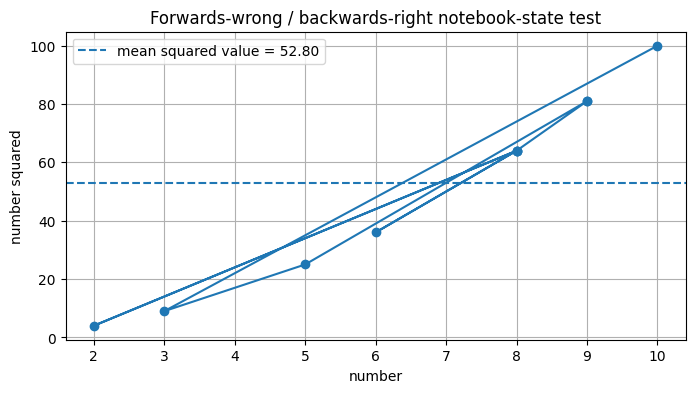

[DONE] Capture 000009: logged 3 artifact(s).


<ExecutionResult object at 22d51942c50, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 22d51942d40, raw_cell="##done before#import matplotlib.plotly as plt
## P.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

In [43]:
%%jupy_capture --label abc-second-pass-a
##done before#import matplotlib.plotly as plt
##  P.S. A does not import matplotlib here because Cell C already did.
##+ This is intentional notebook-state dependence for the A/B/C test.

avg_value = sum(squared_numbers) / len(squared_numbers)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"
)
ax.set_xlabel("number")
ax.set_ylabel("number squared")
ax.grid(True)
ax.legend()

plt.show()

## 15. Code cell         25 — A, first execution: expected failure
#
## and
#
## 20. Code cell (still) 25 — A, second execution: expected success and plot capture
##     call it Code Cell 25/40

In [44]:
## Code cell 26 and 41

dpypd.tree("C:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log")

+ C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
        + 000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
        + 000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
        + 000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
        + 000005_1781784487807_2026-06-18T080807807-0400_tee-basic-input.py
        + 000006_1781784487817_2026-06-18T080807817-0400_tee-basic-stdout.txt
        + 000007_1781784487825_2026-06-18T080807825-0400_tee-basic-display-01-01-text.txt
        + 000008_1781785120346_2026-06-18T081840346-0400_abc-state-reset-input.py
        + 000009_1781785120356_2026-06-18T081840356-0400_abc-state-reset-stdout.txt
        + 000010_1781785610231_2026-06-18T082650231-0400_abc-first-pass-a-input.py
        + 000011_1781785610266_2026-06-18T082650266-0400_abc-first-pass-a-exception.t

---

---

**Something more unexpected!**

I accidentally didn't change the options for my logging, so I ended up with the following from `dpyd.tree`, where I am putting the interesting things in bold.

```text
+ C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
        + 000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
        + 000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
        + 000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
        + 000005_1781784487807_2026-06-18T080807807-0400_tee-basic-input.py
        + 000006_1781784487817_2026-06-18T080807817-0400_tee-basic-stdout.txt
        + 000007_1781784487825_2026-06-18T080807825-0400_tee-basic-display-01-01-text.txt
        + 000008_1781785120346_2026-06-18T081840346-0400_abc-state-reset-input.py
        + 000009_1781785120356_2026-06-18T081840356-0400_abc-state-reset-stdout.txt
```
**`           + 000010_1781785610231_2026-06-18T082650231-0400_abc-first-pass-a-input.py                   .`**<br/>
**`           + 000011_1781785610266_2026-06-18T082650266-0400_abc-first-pass-a-exception.txt              .`**
```text
        + 000012_1781790073348_2026-06-18T094113348-0400_abc-first-pass-b-input.py
        + 000013_1781790073374_2026-06-18T094113374-0400_abc-first-pass-b-exception.txt
        + 000014_1781791465813_2026-06-18T100425813-0400_abc-cell-c-input.py
        + 000015_1781791466557_2026-06-18T100426557-0400_abc-cell-c-stdout.txt
        + 000016_1781793857834_2026-06-18T104417834-0400_abc-second-pass-b-input.py
        + 000017_1781793857846_2026-06-18T104417846-0400_abc-second-pass-b-stdout.txt
```
**`           + 000018_1781798293196_2026-06-18T115813196-0400_abc-first-pass-a-input.py                   .`**<br/>
**`           + 000019_1781798293829_2026-06-18T115813829-0400_abc-first-pass-a-display-01-01-text.txt     .`**<br/>
**`           + 000020_1781798293842_2026-06-18T115813842-0400_abc-first-pass-a-display-01-02-image.png    .`**<br/>
<br/>
**`           + 000021_1781804043242_2026-06-18T133403242-0400_abc-second-pass-a-input.py                  .`**<br/>
**`           + 000022_1781804043385_2026-06-18T133403385-0400_abc-second-pass-a-display-01-01-text.txt    .`**<br/>
**`           + 000023_1781804043391_2026-06-18T133403391-0400_abc-second-pass-a-display-01-02-image.png   .`**<br/>

Basically, I get two sets of files **with the same content**,

1. Three with the wrong labels, coming from<br/>
   &nbsp;&nbsp;&nbsp;&nbsp;`%%jupy_capture --label abc-first-pass-a`<br/>
   during the _second pass_.<br/>
   `first_pass` $\neq$ `second_pass` ... learning time!

`                                                               Important part                           .`<br/>
`                                                                    /                                   .`<br/>
`                                                            |------/\------|                            .`<br/>
`           + 000018_1781798293196_2026-06-18T115813196-0400_abc-first-pass-a-input.py                   .`<br/>
`           + 000019_1781798293829_2026-06-18T115813829-0400_abc-first-pass-a-display-01-01-text.txt     .`<br/>
`           + 000020_1781798293842_2026-06-18T115813842-0400_abc-first-pass-a-display-01-02-image.png    .`<br/>
`                                                            |--------------|                            .`<br/>

2. Three with the right labels, coming from<br/>
   &nbsp;&nbsp;&nbsp;&nbsp;`%%jupy_capture --label abc-second-pass-a`
   during the _second pass_.
   `second_pass` $=$ `second_pass` ... thumbs up!

`                                                            |---------------|                           .`<br/>
`           + 000021_1781804043242_2026-06-18T133403242-0400_abc-second-pass-a-input.py                  .`<br/>
`           + 000022_1781804043385_2026-06-18T133403385-0400_abc-second-pass-a-display-01-01-text.txt    .`<br/>
`           + 000023_1781804043391_2026-06-18T133403391-0400_abc-second-pass-a-display-01-02-image.png   .`<br/>
`                                                            |-------\/------|                           .`<br/>
`                                                                    /                                   .`<br/>
`                                                           Important part                               .`<br/>

There are two previous files that have matching labels with the wrong-label files, but which have content matching the first pass, coming from<br/>
   &nbsp;&nbsp;&nbsp;&nbsp;`%%jupy_capture --label abc-first-pass-a`<br/>
   during the _first pass_.<br/>
   `first_pass` $\neq$ `first_pass` ... thumbs up!

`                                                               Important part                           .`<br/>
`                                                                    /                                   .`<br/>
`                                                            |------/\------|                            .`<br/>
`           + 000010_1781785610231_2026-06-18T082650231-0400_abc-first-pass-a-input.py                   .`<br/>
`           + 000011_1781785610266_2026-06-18T082650266-0400_abc-first-pass-a-exception.txt              .`<br/>
`                                                            |--------------|                            .`<br/>


which is possibly interesting for file compares in later attempts. It's interesting right now to see **how options/parameters match with parts of filenames**. It's especially good to see that we made a good choice in going to the milliseconds, as well as in having monotonic markers.

All right. Good timing for this to happen, since I haven't numbered the **Code cells** much further than this, so I can easily look at a few things. 

In [49]:
# Code cell 42

import contextlib
import io

buffer = io.StringIO()  # string streamer

with contextlib.redirect_stdout(buffer):
    dpypd.tree("C:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log")
##endof:  with contextlib.redirect_stdout(buffer)

tree_out_str = buffer.getvalue()

grep_a_cell_results = [
    line
    for line in tree_out_str.splitlines()
    if r"abc-" in line and r"pass-a-" in line
]

print(*grep_a_cell_results, sep="\n")

        + 000010_1781785610231_2026-06-18T082650231-0400_abc-first-pass-a-input.py
        + 000011_1781785610266_2026-06-18T082650266-0400_abc-first-pass-a-exception.txt
        + 000018_1781798293196_2026-06-18T115813196-0400_abc-first-pass-a-input.py
        + 000019_1781798293829_2026-06-18T115813829-0400_abc-first-pass-a-display-01-01-text.txt
        + 000020_1781798293842_2026-06-18T115813842-0400_abc-first-pass-a-display-01-02-image.png
        + 000021_1781804043242_2026-06-18T133403242-0400_abc-second-pass-a-input.py
        + 000022_1781804043385_2026-06-18T133403385-0400_abc-second-pass-a-display-01-01-text.txt
        + 000023_1781804043391_2026-06-18T133403391-0400_abc-second-pass-a-display-01-02-image.png


In [50]:
## Code cell 43
import filecmp

compare_list = [
    [ 
        "000018_1781798293196_2026-06-18T115813196-0400_abc-first-pass-a-input.py",
        "000021_1781804043242_2026-06-18T133403242-0400_abc-second-pass-a-input.py"
    ],
    [
        "000019_1781798293829_2026-06-18T115813829-0400_abc-first-pass-a-display-01-01-text.txt",
        "000022_1781804043385_2026-06-18T133403385-0400_abc-second-pass-a-display-01-01-text.txt"
    ],
    [
        "000020_1781798293842_2026-06-18T115813842-0400_abc-first-pass-a-display-01-02-image.png",
        "000023_1781804043391_2026-06-18T133403391-0400_abc-second-pass-a-display-01-02-image.png"
    ],
]

for my_pair in compare_list:
    are_identical = filecmp.cmp(
        f"jupy_log/artifacts/{my_pair[0]}", 
        f"jupy_log/artifacts/{my_pair[1]}", 
        shallow=False
    )

    if are_identical:
        print("This pair are identical.")
    ##endof:  if are_identical
##endof:  for my_pair in compare_list

This pair are identical.
This pair are identical.
This pair are identical.


In [51]:
##  Code cell 27 and 44 — Manifest Check

print(
    "----------------------------------------------------------\n" + \
    "___File contents for___\n" + \
    "   'jupy_log/manifest.tsv\n" + \
    "----------------------------------------------------------"
); dpypd.print_file(
    (
        "C:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log/"
        "manifest.tsv"
    )
); print("----------------------------------------------------------")

----------------------------------------------------------
___File contents for___
   'jupy_log/manifest.tsv
----------------------------------------------------------
artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
000001		1781783733033_2026-06-18T075533033-0400	text	text/markdown	literal	details-summary-markdown-regression	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
000002		1781783736601_2026-06-18T075536601-0400	html	text/html	literal	details-summary-html-control	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
000003	000001	1781784186098_2026-06-18T080306098-0400	text	text/x-python	input	capture-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
000004	000001	17817841

In [52]:
##  Code cell 28 and 45, ANYTHING NEW?
##+      MAKE SURE TO MATCH THE FILENAME WITH TREE OUTPUT

hashes="#"*63; dashes="-"*59; equalses="="*59; print_start="___Fil" + \
"e contents for___\n   'jupy_log/"; count_start="___File line coun" + \
"t for___\n   'jupy_log/"; full_stem_path="C:/David/my_repos_dwb/m" + \
"ultimodal-jupy-logger/jupy_log/";      either_end=f"'___\n{dashes}\n";
print(f"{hashes}"); print(); print(f"{dashes}\n");

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000021_1781804043242_2026-06-18T133403242-0400_";
path_third_part ="abc-second-pass-a-input.py";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
the_right_end=contd_bigger_end;
#d.2  #the_right_end=ended_bigger_end;
print(the_right_end)

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000022_1781804043385_2026-06-18T133403385-0400_";
path_third_part ="abc-second-pass-a-display-01-01-text.txt";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
#d.1  #the_right_end=contd_bigger_end;
the_right_end=ended_bigger_end;
print(the_right_end)


## # PHEW! CAUGHT THIS ONE BEFORE RUNNING IT ; )
## the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
## the_right_start = print_start;
## #a.2  #the_right_start = count_start;
## art_str="artifacts/";
## short_pth="";
## dpath_post_jupy_log=f"{art_str}{short_pth}";
## path_second_part="000023_1781804043391_2026-06-18T133403391-0400_g";
## path_third_part ="abc-second-pass-a-display-01-02-image.pn";
## dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
## path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
## f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
## f"{either_end}") ); dpypd.print_file(path_pass) \
## if the_right_start == print_start  else dpypd.count_lines(path_pass); 
## contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
## ended_bigger_end=f"{dashes}\n\n\n{hashes}";
## #d.1  #the_right_end=contd_bigger_end;
## the_right_end=ended_bigger_end;
## print(the_right_end)

###############################################################

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000021_1781804043242_2026-06-18T133403242-0400_
abc-second-pass-a-input.py'___
-----------------------------------------------------------

##done before#import matplotlib.plotly as plt
## P.S. kamMA's Jupyter must not need a numpy import(?)

avg_value = sum(squared_numbers) / len(squared_numbers)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"
)
ax.set_xlabel("number")
ax.set_ylabel("number squared")
ax.grid(True)
ax.legend()

plt.show()

## 15. Code cell         25 — A, first execution: expected failure
#
## and
#
## 20. Code cell (still) 25 — A, second execution: expected success and plo

---

**New stuff after Code cell (27 &amp;) 28, later for (44 &amp;) 45**

<details>
<summary>
    Click the arrow to see the file contents for 
    Code cells (27 &amp; 28) then (44 &amp; 45). 
    Note internal HTML was escaped.
</summary>

<br/><hr/><br/>
**For Code cell 27**

<pre>
----------------------------------------------------------
___File contents for___
   'jupy_log/manifest.tsv
----------------------------------------------------------
artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
000001		1781783733033_2026-06-18T075533033-0400	text	text/markdown	literal	details-summary-markdown-regression	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
000002		1781783736601_2026-06-18T075536601-0400	html	text/html	literal	details-summary-html-control	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
000003	000001	1781784186098_2026-06-18T080306098-0400	text	text/x-python	input	capture-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
000004	000001	1781784186145_2026-06-18T080306145-0400	text	text/plain	stdout	capture-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
000005	000002	1781784487807_2026-06-18T080807807-0400	text	text/x-python	input	tee-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1781784487807_2026-06-18T080807807-0400_tee-basic-input.py
000006	000002	1781784487817_2026-06-18T080807817-0400	text	text/plain	stdout	tee-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1781784487817_2026-06-18T080807817-0400_tee-basic-stdout.txt
000007	000002	1781784487825_2026-06-18T080807825-0400	text	text/plain	display	tee-basic-display-01-01-text	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1781784487825_2026-06-18T080807825-0400_tee-basic-display-01-01-text.txt
000008	000003	1781785120346_2026-06-18T081840346-0400	text	text/x-python	input	abc-state-reset-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1781785120346_2026-06-18T081840346-0400_abc-state-reset-input.py
000009	000003	1781785120356_2026-06-18T081840356-0400	text	text/plain	stdout	abc-state-reset-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1781785120356_2026-06-18T081840356-0400_abc-state-reset-stdout.txt
000010	000004	1781785610231_2026-06-18T082650231-0400	text	text/x-python	input	abc-first-pass-a-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1781785610231_2026-06-18T082650231-0400_abc-first-pass-a-input.py
000011	000004	1781785610266_2026-06-18T082650266-0400	text	text/plain	exception	abc-first-pass-a-exception	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1781785610266_2026-06-18T082650266-0400_abc-first-pass-a-exception.txt
----------------------------------------------------------
</pre>

<br/><hr/><br/>
**For code cell 28**

<pre>
###############################################################

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000010_1781785610231_2026-06-18T082650231-0400_
abc-first-pass-a-input.py'___
-----------------------------------------------------------

##done before#import matplotlib.plotly as plt
## P.S. kamMA's Jupyter must not need a numpy import(?)

avg_value = sum(squared_numbers) / len(squared_numbers)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"
)
ax.set_xlabel("number")
ax.set_ylabel("number squared")
ax.grid(True)
ax.legend()

plt.show()

## 15. Code cell         25 — A, first execution: expected failure
#
## and
#
## 20. Code cell (still) 25 — A, second execution: expected success and plot capture
-----------------------------------------------------------
===========================================================

===========================================================
-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000011_1781785610266_2026-06-18T082650266-0400_
abc-first-pass-a-exception.txt'___
-----------------------------------------------------------

Traceback (most recent call last):
  File "C:\David\my_repos_dwb\multimodal-jupy-logger\.venv_test_mmjl\lib\site-packages\IPython\core\interactiveshell.py", line 3579, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\Anast\AppData\Local\Temp\ipykernel_20120\1351919060.py", line 4, in <module>
    avg_value = sum(squared_numbers) / len(squared_numbers)
NameError: name 'squared_numbers' is not defined
-----------------------------------------------------------


###############################################################
</pre>

<br/><hr/><br/>

**Note for Cell A (second), Code cell 40**

<div style="background-color: cyan; max-width: 750px; width: fit-content;">
<span style="font-family: monospace;">
<strong><em>
That plot has a very interesting way of showing that one degenerate<br/>
(repeated, degenerate might not be the right word, eh kamMA?) value is 
64<br/>
in <code style="background-color: cyan;">squared_numbers</code>, seen 
in the plot on the x-axis as 8 
in <code style="background-color: cyan;">numbers</code>.<br/>
One can see that more than two lines <em>come in</em>/<em>go out</em> at
(8, 64).<br/>
(9, 81) is another repeated value pair. The reason we don&apos;t 
see<br/>
the extra visits is simple.
</em></strong>
</span>

<div style="background-color: white"><br></div>

<details>
<summary>
<span style="font-family: monospace;">
<strong><em>Click to see the reason, 
if nested details/summary tags are allowed.</em></strong>
</span>
</summary>

<div style="background-color: white;">They are allowed!</div>
    

<div style="background-color: #FF8B00;">
The <code style="background-color: #FF8B00;">numbers</code> array is 
represented 
as <code style="background-color: #FF8B00;"
       >[8  2  8  6  8  9  9  5  3  10]</code>.

First of all, 9 goes from itself to itself in a connected scatter plot
(not the best choice of visualization in this situation, we will have
 to discuss that, kamMA.) The scatter plot makes things interesting in
another way; If we trace traversals between numbers, we can see that
several paths are traversed mutliple times. Let's walk the whole...
graph-like thingie, then order each path from small number to big,
then group our edge-like thingies.

<code style="background-color: #FF8B00;"
    >(8 → 2, 2 → 8, 8 → 6, 6 → 8, 8 → 9, 9 → 9, 9 → 5, 5 → 3, 3 → 10)</code>

each directed segment (-ish) becomes an edge (-ish) when one goes
<code style="background-color: #FF8B00;"
    >smaller ↔ same-or-larger</code> in every case.

<code style="background-color: #FF8B00;"
    >(2 ↔ 8, 2 ↔ 8, 6 ↔ 8, 6 ↔ 8, 8 ↔ 9, 9 ↔ 9, 5 ↔ 9, 3 ↔ 5, 3 ↔ 10)</code>

Now, we can order and group these, comparing firsts, and if the firsts
are the same, comparing seconds.

<code style="background-color: #FF8B00;"
    >(
  2↔8, 2↔8,  # Edge traversed twice
  3↔5,
  3↔10,
  5↔9,
  6↔8, 6↔8,  # Edge traversed twice
  8↔9,
  9↔9
)</code>

So we have two edges traversed twice. What an unnecessary but
interesting tangent. I was just trying to figure out how I could
analyze the distribution. So maybe not completely unnecessary ; )
Eh, kamMA?
</div>
</div>

</details>

<br/>

<span style="font-family: monospace; background-color: cyan;"
    ><strong><em>Cyan to draw 
    kamMA&apos;s attention!!!</em></strong></span>

<br/><hr/><br/>
**For code cell 44** 

<pre>
----------------------------------------------------------
___File contents for___
   'jupy_log/manifest.tsv
----------------------------------------------------------
artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
000001		1781783733033_2026-06-18T075533033-0400	text	text/markdown	literal	details-summary-markdown-regression	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
000002		1781783736601_2026-06-18T075536601-0400	html	text/html	literal	details-summary-html-control	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
000003	000001	1781784186098_2026-06-18T080306098-0400	text	text/x-python	input	capture-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
000004	000001	1781784186145_2026-06-18T080306145-0400	text	text/plain	stdout	capture-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
000005	000002	1781784487807_2026-06-18T080807807-0400	text	text/x-python	input	tee-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1781784487807_2026-06-18T080807807-0400_tee-basic-input.py
000006	000002	1781784487817_2026-06-18T080807817-0400	text	text/plain	stdout	tee-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1781784487817_2026-06-18T080807817-0400_tee-basic-stdout.txt
000007	000002	1781784487825_2026-06-18T080807825-0400	text	text/plain	display	tee-basic-display-01-01-text	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1781784487825_2026-06-18T080807825-0400_tee-basic-display-01-01-text.txt
000008	000003	1781785120346_2026-06-18T081840346-0400	text	text/x-python	input	abc-state-reset-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1781785120346_2026-06-18T081840346-0400_abc-state-reset-input.py
000009	000003	1781785120356_2026-06-18T081840356-0400	text	text/plain	stdout	abc-state-reset-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1781785120356_2026-06-18T081840356-0400_abc-state-reset-stdout.txt
000010	000004	1781785610231_2026-06-18T082650231-0400	text	text/x-python	input	abc-first-pass-a-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1781785610231_2026-06-18T082650231-0400_abc-first-pass-a-input.py
000011	000004	1781785610266_2026-06-18T082650266-0400	text	text/plain	exception	abc-first-pass-a-exception	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1781785610266_2026-06-18T082650266-0400_abc-first-pass-a-exception.txt
000012	000005	1781790073348_2026-06-18T094113348-0400	text	text/x-python	input	abc-first-pass-b-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1781790073348_2026-06-18T094113348-0400_abc-first-pass-b-input.py
000013	000005	1781790073374_2026-06-18T094113374-0400	text	text/plain	exception	abc-first-pass-b-exception	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1781790073374_2026-06-18T094113374-0400_abc-first-pass-b-exception.txt
000014	000006	1781791465813_2026-06-18T100425813-0400	text	text/x-python	input	abc-cell-c-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000014_1781791465813_2026-06-18T100425813-0400_abc-cell-c-input.py
000015	000006	1781791466557_2026-06-18T100426557-0400	text	text/plain	stdout	abc-cell-c-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000015_1781791466557_2026-06-18T100426557-0400_abc-cell-c-stdout.txt
000016	000007	1781793857834_2026-06-18T104417834-0400	text	text/x-python	input	abc-second-pass-b-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000016_1781793857834_2026-06-18T104417834-0400_abc-second-pass-b-input.py
000017	000007	1781793857846_2026-06-18T104417846-0400	text	text/plain	stdout	abc-second-pass-b-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000017_1781793857846_2026-06-18T104417846-0400_abc-second-pass-b-stdout.txt
000018	000008	1781798293196_2026-06-18T115813196-0400	text	text/x-python	input	abc-first-pass-a-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000018_1781798293196_2026-06-18T115813196-0400_abc-first-pass-a-input.py
000019	000008	1781798293829_2026-06-18T115813829-0400	text	text/plain	display	abc-first-pass-a-display-01-01-text	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000019_1781798293829_2026-06-18T115813829-0400_abc-first-pass-a-display-01-01-text.txt
000020	000008	1781798293842_2026-06-18T115813842-0400	image	image/png	display	abc-first-pass-a-display-01-02-image	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000020_1781798293842_2026-06-18T115813842-0400_abc-first-pass-a-display-01-02-image.png
000021	000009	1781804043242_2026-06-18T133403242-0400	text	text/x-python	input	abc-second-pass-a-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000021_1781804043242_2026-06-18T133403242-0400_abc-second-pass-a-input.py
000022	000009	1781804043385_2026-06-18T133403385-0400	text	text/plain	display	abc-second-pass-a-display-01-01-text	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000022_1781804043385_2026-06-18T133403385-0400_abc-second-pass-a-display-01-01-text.txt
000023	000009	1781804043391_2026-06-18T133403391-0400	image	image/png	display	abc-second-pass-a-display-01-02-image	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000023_1781804043391_2026-06-18T133403391-0400_abc-second-pass-a-display-01-02-image.png
----------------------------------------------------------
</pre>

<br/><hr/><br/>
**For code cell 45**

<pre>
###############################################################

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000021_1781804043242_2026-06-18T133403242-0400_
abc-second-pass-a-input.py'___
-----------------------------------------------------------

##done before#import matplotlib.plotly as plt
## P.S. kamMA's Jupyter must not need a numpy import(?)

avg_value = sum(squared_numbers) / len(squared_numbers)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"
)
ax.set_xlabel("number")
ax.set_ylabel("number squared")
ax.grid(True)
ax.legend()

plt.show()

## 15. Code cell         25 — A, first execution: expected failure
#
## and
#
## 20. Code cell (still) 25 — A, second execution: expected success and plot capture
##     call it Code Cell 25/40
-----------------------------------------------------------
===========================================================

===========================================================
-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000022_1781804043385_2026-06-18T133403385-0400_
abc-second-pass-a-display-01-01-text.txt'___
-----------------------------------------------------------

<Figure size 800x400 with 1 Axes>-----------------------------------------------------------


###############################################################

</details>

<hr/>

---

**If you have finished A, B, C, then back to B, A**

**It's time to go to Code cell 46**, which is at **\## 19**, the crossed out `h2`.

[Here](#19.Code-cell-—-configure-Matplotlib-inline-rendering), I got you the link... that never seems to work.

---

You can skip the next stuff if you've done B and A twice. Otherwise, keep going down.

---

---

**`=============`**<br/>
**`Cell B, below`**<br/>
**`=============`**<br/>
- For **16** (`Code cell         29 — first execution: expected failure`)

  - Expected result:

```text
NameError involving squared_numbers
```

  - The capture should still log:

    * the input
    * the exception
    * any output produced before the exception, if present

  - ACTUAL OUTPUT:

```text
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[30], line 3
      1 squared_numbers = [
      2     number ** 2
----> 3     for number in numbers
      4 ]
      6 print("squared_numbers:", squared_numbers)
      8 ## 16. Code cell         29 — B, first execution: expected failure
      9 #
     10 ## and
     11 #
     12 ## 18. Code cell (still) 29 — B, second execution: expected success

NameError: name 'numbers' is not defined
[DONE] Capture 000005: logged 2 artifact(s).
[MMJL] %%jupy_capture captured an execution error.
<ExecutionResult object at 22d51823640, execution_count=None error_before_exec=None error_in_exec=name 'numbers' is not defined info=<ExecutionInfo object at 22d518235b0, raw_cell="squared_numbers = [
    number ** 2
    for number.." store_history=False silent=False shell_futures=True cell_id=None> result=None>
```

  - Output of `dpypd.tree()`

```text
+ C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
        + 000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
        + 000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
        + 000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
        + 000005_1781784487807_2026-06-18T080807807-0400_tee-basic-input.py
        + 000006_1781784487817_2026-06-18T080807817-0400_tee-basic-stdout.txt
        + 000007_1781784487825_2026-06-18T080807825-0400_tee-basic-display-01-01-text.txt
        + 000008_1781785120346_2026-06-18T081840346-0400_abc-state-reset-input.py
        + 000009_1781785120356_2026-06-18T081840356-0400_abc-state-reset-stdout.txt
        + 000010_1781785610231_2026-06-18T082650231-0400_abc-first-pass-a-input.py
        + 000011_1781785610266_2026-06-18T082650266-0400_abc-first-pass-a-exception.txt
        + 000012_1781790073348_2026-06-18T094113348-0400_abc-first-pass-b-input.py
        + 000013_1781790073374_2026-06-18T094113374-0400_abc-first-pass-b-exception.txt
    + manifest.tsv
```

  - ~~Relevant~~ All content of `manifest.tsv` manifest

```text
artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
000001		1781783733033_2026-06-18T075533033-0400	text	text/markdown	literal	details-summary-markdown-regression	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
000002		1781783736601_2026-06-18T075536601-0400	html	text/html	literal	details-summary-html-control	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
000003	000001	1781784186098_2026-06-18T080306098-0400	text	text/x-python	input	capture-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
000004	000001	1781784186145_2026-06-18T080306145-0400	text	text/plain	stdout	capture-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
000005	000002	1781784487807_2026-06-18T080807807-0400	text	text/x-python	input	tee-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1781784487807_2026-06-18T080807807-0400_tee-basic-input.py
000006	000002	1781784487817_2026-06-18T080807817-0400	text	text/plain	stdout	tee-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1781784487817_2026-06-18T080807817-0400_tee-basic-stdout.txt
000007	000002	1781784487825_2026-06-18T080807825-0400	text	text/plain	display	tee-basic-display-01-01-text	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1781784487825_2026-06-18T080807825-0400_tee-basic-display-01-01-text.txt
000008	000003	1781785120346_2026-06-18T081840346-0400	text	text/x-python	input	abc-state-reset-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1781785120346_2026-06-18T081840346-0400_abc-state-reset-input.py
000009	000003	1781785120356_2026-06-18T081840356-0400	text	text/plain	stdout	abc-state-reset-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1781785120356_2026-06-18T081840356-0400_abc-state-reset-stdout.txt
000010	000004	1781785610231_2026-06-18T082650231-0400	text	text/x-python	input	abc-first-pass-a-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1781785610231_2026-06-18T082650231-0400_abc-first-pass-a-input.py
000011	000004	1781785610266_2026-06-18T082650266-0400	text	text/plain	exception	abc-first-pass-a-exception	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1781785610266_2026-06-18T082650266-0400_abc-first-pass-a-exception.txt
000012	000005	1781790073348_2026-06-18T094113348-0400	text	text/x-python	input	abc-first-pass-b-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1781790073348_2026-06-18T094113348-0400_abc-first-pass-b-input.py
000013	000005	1781790073374_2026-06-18T094113374-0400	text	text/plain	exception	abc-first-pass-b-exception	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1781790073374_2026-06-18T094113374-0400_abc-first-pass-b-exception.txt
```

  - Content of `000012_1781790073348_2026-06-18T094113348-0400_abc-first-pass-b-input.py` input text (code)

```python
squared_numbers = [
    number ** 2
    for number in numbers
]

print("squared_numbers:", squared_numbers)

## 16. Code cell         29 — B, first execution: expected failure
#
## and
#
## 18. Code cell (still) 29 — B, second execution: expected success
```

  - Content of `000013_1781790073374_2026-06-18T094113374-0400_abc-first-pass-b-exception.txt` output text (exception)

```text
Traceback (most recent call last):
  File "C:\David\my_repos_dwb\multimodal-jupy-logger\.venv_test_mmjl\lib\site-packages\IPython\core\interactiveshell.py", line 3579, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\Anast\AppData\Local\Temp\ipykernel_20120\3882119948.py", line 3, in <module>
    for number in numbers
NameError: name 'numbers' is not defined
```

<br/>
<strike>
_(maybe?)_

  - Content of `000014_` output text (???)

```text
Lorem ipsum
```
</strike>
<br/>

<!-- Put the following back in, if needed, with comment to the right -->
**NOTE, KAMMA, THAT THERE IS NOTHING FOR THE NON-EXCEPTION OUTPUT**,
which I'll show bolded in between the beginnings and endings of (non-bold) exception text.

`NameError: name 'numbers' is not defined`<br/>
**`[DONE] Capture 000005: logged 2 artifact(s).`**<br/>
`[MMJL] %%jupy_capture captured an execution error.`<br/>
**`<ExecutionResult object at 22d51823640, execution_count=None error_before_exec=None error_in_exec=name 'numbers' is not defined info=<ExecutionInfo object at 22d518235b0, raw_cell="squared_numbers = [     number \*\* 2`**<br/>
**`    for number.." store_history=False silent=False shell_futures=True cell_id=None> result=None>`**
                                            <!-- Use left to comment to put back previous -->

---

- For **18** (`Code cell (still) 29 — second execution: expected success`)
- This would be code cell 36, so I'm going to call it **29/36**
  - The only difference in the input is the change,
    - from:
      - `%%jupy_capture --label abc-first-pass-b`
    - to:
      - `%%jupy_capture --label abc-second-pass-b`
  
  - ACTUAL OUTPUT
 
```text
squared_numbers: [np.int64(64), np.int64(4), np.int64(64), np.int64(36), np.int64(64), np.int64(81), np.int64(81), np.int64(25), np.int64(9), np.int64(100)]
[DONE] Capture 000007: logged 2 artifact(s).
<ExecutionResult object at 22d5113c280, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 22d5113fe50, raw_cell="squared_numbers = [
    number ** 2
    for number.." store_history=False silent=False shell_futures=True cell_id=None> result=None>
```

The rest of the successful run's files' contents can be seen in the output of Code cells **37** (with 30/**37**), **38** (with 31/**38**), and **39** (with 32/**39**)

In [37]:
%%jupy_capture --label abc-second-pass-b
squared_numbers = [
    number ** 2
    for number in numbers
]

print("squared_numbers:", squared_numbers)

## 16. Code cell         29 — B, first execution: expected failure
#
## and
#
## 18. Code cell (still) 29 — B, second execution: expected success
##     call it Code cell 29/36

squared_numbers: [np.int64(64), np.int64(4), np.int64(64), np.int64(36), np.int64(64), np.int64(81), np.int64(81), np.int64(25), np.int64(9), np.int64(100)]
[DONE] Capture 000007: logged 2 artifact(s).


<ExecutionResult object at 22d5113c280, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 22d5113fe50, raw_cell="squared_numbers = [
    number ** 2
    for number.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

In [38]:
## Code cell 30/37

dpypd.tree("C:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log")

+ C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
        + 000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
        + 000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
        + 000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
        + 000005_1781784487807_2026-06-18T080807807-0400_tee-basic-input.py
        + 000006_1781784487817_2026-06-18T080807817-0400_tee-basic-stdout.txt
        + 000007_1781784487825_2026-06-18T080807825-0400_tee-basic-display-01-01-text.txt
        + 000008_1781785120346_2026-06-18T081840346-0400_abc-state-reset-input.py
        + 000009_1781785120356_2026-06-18T081840356-0400_abc-state-reset-stdout.txt
        + 000010_1781785610231_2026-06-18T082650231-0400_abc-first-pass-a-input.py
        + 000011_1781785610266_2026-06-18T082650266-0400_abc-first-pass-a-exception.t

In [39]:
##  Code cell 31/38 — Manifest Check?

print(
    "----------------------------------------------------------\n" + \
    "___File contents for___\n" + \
    "   'jupy_log/manifest.tsv\n" + \
    "----------------------------------------------------------"
); dpypd.print_file(
    (
        "C:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log/"
        "manifest.tsv"
    )
); print("----------------------------------------------------------")

----------------------------------------------------------
___File contents for___
   'jupy_log/manifest.tsv
----------------------------------------------------------
artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
000001		1781783733033_2026-06-18T075533033-0400	text	text/markdown	literal	details-summary-markdown-regression	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
000002		1781783736601_2026-06-18T075536601-0400	html	text/html	literal	details-summary-html-control	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
000003	000001	1781784186098_2026-06-18T080306098-0400	text	text/x-python	input	capture-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
000004	000001	17817841

In [40]:
##  Code cell 32/39, ANYTHING NEW?
##+      MAKE SURE TO MATCH THE FILENAME WITH TREE OUTPUT

hashes="#"*63; dashes="-"*59; equalses="="*59; print_start="___Fil" + \
"e contents for___\n   'jupy_log/"; count_start="___File line coun" + \
"t for___\n   'jupy_log/"; full_stem_path="C:/David/my_repos_dwb/m" + \
"ultimodal-jupy-logger/jupy_log/";      either_end=f"'___\n{dashes}\n";
print(f"{hashes}"); print(); print(f"{dashes}\n");

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000016_1781793857834_2026-06-18T104417834-0400_";
path_third_part ="abc-second-pass-b-input.py";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
the_right_end=contd_bigger_end;
#d.2  #the_right_end=ended_bigger_end;
print(the_right_end)

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000017_1781793857846_2026-06-18T104417846-0400_";
path_third_part ="abc-second-pass-b-stdout.txt";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
#d.1  #the_right_end=contd_bigger_end;
the_right_end=ended_bigger_end;
print(the_right_end)

###############################################################

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000016_1781793857834_2026-06-18T104417834-0400_
abc-second-pass-b-input.py'___
-----------------------------------------------------------

squared_numbers = [
    number ** 2
    for number in numbers
]

print("squared_numbers:", squared_numbers)

## 16. Code cell         29 — B, first execution: expected failure
#
## and
#
## 18. Code cell (still) 29 — B, second execution: expected success
##     call it Code cell 29/36
-----------------------------------------------------------

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000017_1781793857846_2026-06-18T104417846-0400_
abc-second-pass-b-stdout.txt'___
-----------------------------------------------------------

squared_numbers: [np.int64(64), np.int64(4), np.int64(64), np.int64(36), np.int64(64), n

**New stuff after Code cell (31 &amp; ) 32, later for (38 &amp;) 39**

_Those all relate to **Cell B**_

<details>
<summary>
    Click the arrow to see the file contents for 
    Code cells (31 &amp; 32) then (38 &amp; 39).
    All related to <strong>Cell B</strong>.
    Note internal HTML was escaped.
</summary>

<br/><hr/><br/>
**For Code cell 31**

<pre>
----------------------------------------------------------
___File contents for___
   'jupy_log/manifest.tsv
----------------------------------------------------------
artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
000001		1781783733033_2026-06-18T075533033-0400	text	text/markdown	literal	details-summary-markdown-regression	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
000002		1781783736601_2026-06-18T075536601-0400	html	text/html	literal	details-summary-html-control	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
000003	000001	1781784186098_2026-06-18T080306098-0400	text	text/x-python	input	capture-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
000004	000001	1781784186145_2026-06-18T080306145-0400	text	text/plain	stdout	capture-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
000005	000002	1781784487807_2026-06-18T080807807-0400	text	text/x-python	input	tee-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1781784487807_2026-06-18T080807807-0400_tee-basic-input.py
000006	000002	1781784487817_2026-06-18T080807817-0400	text	text/plain	stdout	tee-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1781784487817_2026-06-18T080807817-0400_tee-basic-stdout.txt
000007	000002	1781784487825_2026-06-18T080807825-0400	text	text/plain	display	tee-basic-display-01-01-text	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1781784487825_2026-06-18T080807825-0400_tee-basic-display-01-01-text.txt
000008	000003	1781785120346_2026-06-18T081840346-0400	text	text/x-python	input	abc-state-reset-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1781785120346_2026-06-18T081840346-0400_abc-state-reset-input.py
000009	000003	1781785120356_2026-06-18T081840356-0400	text	text/plain	stdout	abc-state-reset-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1781785120356_2026-06-18T081840356-0400_abc-state-reset-stdout.txt
000010	000004	1781785610231_2026-06-18T082650231-0400	text	text/x-python	input	abc-first-pass-a-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1781785610231_2026-06-18T082650231-0400_abc-first-pass-a-input.py
000011	000004	1781785610266_2026-06-18T082650266-0400	text	text/plain	exception	abc-first-pass-a-exception	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1781785610266_2026-06-18T082650266-0400_abc-first-pass-a-exception.txt
000012	000005	1781790073348_2026-06-18T094113348-0400	text	text/x-python	input	abc-first-pass-b-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1781790073348_2026-06-18T094113348-0400_abc-first-pass-b-input.py
000013	000005	1781790073374_2026-06-18T094113374-0400	text	text/plain	exception	abc-first-pass-b-exception	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1781790073374_2026-06-18T094113374-0400_abc-first-pass-b-exception.txt
----------------------------------------------------------
</pre>

<br/><hr/><br/>
**For Code cell 32**

<pre>
###############################################################

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000012_1781790073348_2026-06-18T094113348-0400_
abc-first-pass-b-input.py'___
-----------------------------------------------------------

squared_numbers = [
    number ** 2
    for number in numbers
]

print("squared_numbers:", squared_numbers)

## 16. Code cell         29 — B, first execution: expected failure
#
## and
#
## 18. Code cell (still) 29 — B, second execution: expected success
-----------------------------------------------------------
===========================================================

===========================================================
-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000013_1781790073374_2026-06-18T094113374-0400_
abc-first-pass-b-exception.txt'___
-----------------------------------------------------------

Traceback (most recent call last):
  File "C:\David\my_repos_dwb\multimodal-jupy-logger\.venv_test_mmjl\lib\site-packages\IPython\core\interactiveshell.py", line 3579, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\Anast\AppData\Local\Temp\ipykernel_20120\3882119948.py", line 3, in <module>
    for number in numbers
NameError: name 'numbers' is not defined
-----------------------------------------------------------


##############################################################
</pre>

<br/><hr/><br/>
**For Code cell 38**

```text
----------------------------------------------------------
___File contents for___
   'jupy_log/manifest.tsv
----------------------------------------------------------
artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
000001		1781783733033_2026-06-18T075533033-0400	text	text/markdown	literal	details-summary-markdown-regression	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
000002		1781783736601_2026-06-18T075536601-0400	html	text/html	literal	details-summary-html-control	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
000003	000001	1781784186098_2026-06-18T080306098-0400	text	text/x-python	input	capture-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
000004	000001	1781784186145_2026-06-18T080306145-0400	text	text/plain	stdout	capture-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
000005	000002	1781784487807_2026-06-18T080807807-0400	text	text/x-python	input	tee-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1781784487807_2026-06-18T080807807-0400_tee-basic-input.py
000006	000002	1781784487817_2026-06-18T080807817-0400	text	text/plain	stdout	tee-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1781784487817_2026-06-18T080807817-0400_tee-basic-stdout.txt
000007	000002	1781784487825_2026-06-18T080807825-0400	text	text/plain	display	tee-basic-display-01-01-text	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1781784487825_2026-06-18T080807825-0400_tee-basic-display-01-01-text.txt
000008	000003	1781785120346_2026-06-18T081840346-0400	text	text/x-python	input	abc-state-reset-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1781785120346_2026-06-18T081840346-0400_abc-state-reset-input.py
000009	000003	1781785120356_2026-06-18T081840356-0400	text	text/plain	stdout	abc-state-reset-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1781785120356_2026-06-18T081840356-0400_abc-state-reset-stdout.txt
000010	000004	1781785610231_2026-06-18T082650231-0400	text	text/x-python	input	abc-first-pass-a-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1781785610231_2026-06-18T082650231-0400_abc-first-pass-a-input.py
000011	000004	1781785610266_2026-06-18T082650266-0400	text	text/plain	exception	abc-first-pass-a-exception	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1781785610266_2026-06-18T082650266-0400_abc-first-pass-a-exception.txt
000012	000005	1781790073348_2026-06-18T094113348-0400	text	text/x-python	input	abc-first-pass-b-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1781790073348_2026-06-18T094113348-0400_abc-first-pass-b-input.py
000013	000005	1781790073374_2026-06-18T094113374-0400	text	text/plain	exception	abc-first-pass-b-exception	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1781790073374_2026-06-18T094113374-0400_abc-first-pass-b-exception.txt
000014	000006	1781791465813_2026-06-18T100425813-0400	text	text/x-python	input	abc-cell-c-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000014_1781791465813_2026-06-18T100425813-0400_abc-cell-c-input.py
000015	000006	1781791466557_2026-06-18T100426557-0400	text	text/plain	stdout	abc-cell-c-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000015_1781791466557_2026-06-18T100426557-0400_abc-cell-c-stdout.txt
000016	000007	1781793857834_2026-06-18T104417834-0400	text	text/x-python	input	abc-second-pass-b-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000016_1781793857834_2026-06-18T104417834-0400_abc-second-pass-b-input.py
000017	000007	1781793857846_2026-06-18T104417846-0400	text	text/plain	stdout	abc-second-pass-b-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000017_1781793857846_2026-06-18T104417846-0400_abc-second-pass-b-stdout.txt
----------------------------------------------------------
```

<br/><hr/><br/>
**For Code cell 39**

```text
###############################################################

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000016_1781793857834_2026-06-18T104417834-0400_
abc-second-pass-b-input.py'___
-----------------------------------------------------------

squared_numbers = [
    number ** 2
    for number in numbers
]

print("squared_numbers:", squared_numbers)

## 16. Code cell         29 — B, first execution: expected failure
#
## and
#
## 18. Code cell (still) 29 — B, second execution: expected success
##     call it Code cell 29/36
-----------------------------------------------------------
===========================================================

===========================================================
-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000017_1781793857846_2026-06-18T104417846-0400_
abc-second-pass-b-stdout.txt'___
-----------------------------------------------------------

squared_numbers: [np.int64(64), np.int64(4), np.int64(64), np.int64(36), np.int64(64), np.int64(81), np.int64(81), np.int64(25), np.int64(9), np.int64(100)]
-----------------------------------------------------------


###############################################################
```

</details>

<hr/>

**`=============`**<br/>
**`Cell C, below`**<br/>
**`=============`**<br/>
- For **17** (`Code cell 33 — C: expected success`)

  - Expected result:
    - Success. 
  - File contents for successful run
    - Look at the output of **Code cell 35**
  - ACTUAL OUTPUT

```text
numbers: [ 8  2  8  6  8  9  9  5  3 10]
[DONE] Capture 000006: logged 2 artifact(s).
<ExecutionResult object at 22d5113c430, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 22d5113d480, raw_cell="import numpy as np
import matplotlib.pyplot as plt.." store_history=False silent=False shell_futures=True cell_id=None> result=None>
```


In [34]:
%%jupy_capture --label abc-cell-c
import numpy as np
import matplotlib.pyplot as plt

# numbers = [
#     -5,
#     -3,
#     -1,
#     0,
#     2,
#     4,
#     6,
# ]

## Older global-random-state style, like MLU
# numbers = np.random.randint(1, 11, size=10)


rng = np.random.default_rng()
numbers = rng.integers(1, 11, size=10)

print("numbers:", numbers)

## 17. Code cell 33 — C: expected success

numbers: [ 8  2  8  6  8  9  9  5  3 10]
[DONE] Capture 000006: logged 2 artifact(s).


<ExecutionResult object at 22d5113c430, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 22d5113d480, raw_cell="import numpy as np
import matplotlib.pyplot as plt.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

In [35]:
## Code cell 34

dpypd.tree("C:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log")

+ C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
        + 000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
        + 000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
        + 000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
        + 000005_1781784487807_2026-06-18T080807807-0400_tee-basic-input.py
        + 000006_1781784487817_2026-06-18T080807817-0400_tee-basic-stdout.txt
        + 000007_1781784487825_2026-06-18T080807825-0400_tee-basic-display-01-01-text.txt
        + 000008_1781785120346_2026-06-18T081840346-0400_abc-state-reset-input.py
        + 000009_1781785120356_2026-06-18T081840356-0400_abc-state-reset-stdout.txt
        + 000010_1781785610231_2026-06-18T082650231-0400_abc-first-pass-a-input.py
        + 000011_1781785610266_2026-06-18T082650266-0400_abc-first-pass-a-exception.t

In [36]:
##  Code cell 35 — ANYTHING NEW?
##+      MAKE SURE TO MATCH THE FILENAME WITH TREE OUTPUT

## ALSO INCLUDES THE MANIFEST CHECK ##

hashes="#"*63; dashes="-"*59; equalses="="*59; print_start="___Fil" + \
"e contents for___\n   'jupy_log/"; count_start="___File line coun" + \
"t for___\n   'jupy_log/"; full_stem_path="C:/David/my_repos_dwb/m" + \
"ultimodal-jupy-logger/jupy_log/";      either_end=f"'___\n{dashes}\n";
print(f"{hashes}"); print(); print(f"{dashes}\n");

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000014_1781791465813_2026-06-18T100425813-0400_";
path_third_part ="abc-cell-c-input.py";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
the_right_end=contd_bigger_end;
#d.2  #the_right_end=ended_bigger_end;
print(the_right_end)

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000015_1781791466557_2026-06-18T100426557-0400_";
path_third_part ="abc-cell-c-stdout.txt";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
the_right_end=contd_bigger_end;
#d.2  #the_right_end=ended_bigger_end;
print(the_right_end)

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
# b   #art_str="artifacts/";
short_pth="manifest.tsv";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="";
path_third_part ="";
# c.2#dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
#d.1  #the_right_end=contd_bigger_end;
the_right_end=ended_bigger_end;
print(the_right_end)

###############################################################

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000014_1781791465813_2026-06-18T100425813-0400_
abc-cell-c-input.py'___
-----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# numbers = [
#     -5,
#     -3,
#     -1,
#     0,
#     2,
#     4,
#     6,
# ]

## Older global-random-state style, like MLU
# numbers = np.random.randint(1, 11, size=10)


rng = np.random.default_rng()
numbers = rng.integers(1, 11, size=10)

print("numbers:", numbers)

## 17. Code cell 34 — C: expected success
-----------------------------------------------------------

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000015_1781791466557_2026-06-18T100426557-0400_
abc-cell-c-stdout.txt'___
-----------------------------------------------------------

numbers: [ 8  2  8

**New stuff after Code cell 35**

_Those all relate to **Cell C**_

<details>
<summary>
    Click the arrow to see the file contents. 
    All related to <strong>Cell C</strong>.
    Note internal HTML was escaped.
</summary>

<pre>
###############################################################

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000014_1781791465813_2026-06-18T100425813-0400_
abc-cell-c-input.py'___
-----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# numbers = [
#     -5,
#     -3,
#     -1,
#     0,
#     2,
#     4,
#     6,
# ]

## Older global-random-state style, like MLU
# numbers = np.random.randint(1, 11, size=10)


rng = np.random.default_rng()
numbers = rng.integers(1, 11, size=10)

print("numbers:", numbers)

## 17. Code cell 34 — C: expected success
-----------------------------------------------------------
===========================================================

===========================================================
-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000015_1781791466557_2026-06-18T100426557-0400_
abc-cell-c-stdout.txt'___
-----------------------------------------------------------

numbers: [ 8  2  8  6  8  9  9  5  3 10]
-----------------------------------------------------------
===========================================================

===========================================================
-----------------------------------------------------------

___File contents for___
   'jupy_log/manifest.tsv'___
-----------------------------------------------------------

artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
000001		1781783733033_2026-06-18T075533033-0400	text	text/markdown	literal	details-summary-markdown-regression	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
000002		1781783736601_2026-06-18T075536601-0400	html	text/html	literal	details-summary-html-control	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
000003	000001	1781784186098_2026-06-18T080306098-0400	text	text/x-python	input	capture-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
000004	000001	1781784186145_2026-06-18T080306145-0400	text	text/plain	stdout	capture-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
000005	000002	1781784487807_2026-06-18T080807807-0400	text	text/x-python	input	tee-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1781784487807_2026-06-18T080807807-0400_tee-basic-input.py
000006	000002	1781784487817_2026-06-18T080807817-0400	text	text/plain	stdout	tee-basic-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1781784487817_2026-06-18T080807817-0400_tee-basic-stdout.txt
000007	000002	1781784487825_2026-06-18T080807825-0400	text	text/plain	display	tee-basic-display-01-01-text	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1781784487825_2026-06-18T080807825-0400_tee-basic-display-01-01-text.txt
000008	000003	1781785120346_2026-06-18T081840346-0400	text	text/x-python	input	abc-state-reset-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1781785120346_2026-06-18T081840346-0400_abc-state-reset-input.py
000009	000003	1781785120356_2026-06-18T081840356-0400	text	text/plain	stdout	abc-state-reset-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1781785120356_2026-06-18T081840356-0400_abc-state-reset-stdout.txt
000010	000004	1781785610231_2026-06-18T082650231-0400	text	text/x-python	input	abc-first-pass-a-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1781785610231_2026-06-18T082650231-0400_abc-first-pass-a-input.py
000011	000004	1781785610266_2026-06-18T082650266-0400	text	text/plain	exception	abc-first-pass-a-exception	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1781785610266_2026-06-18T082650266-0400_abc-first-pass-a-exception.txt
000012	000005	1781790073348_2026-06-18T094113348-0400	text	text/x-python	input	abc-first-pass-b-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1781790073348_2026-06-18T094113348-0400_abc-first-pass-b-input.py
000013	000005	1781790073374_2026-06-18T094113374-0400	text	text/plain	exception	abc-first-pass-b-exception	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1781790073374_2026-06-18T094113374-0400_abc-first-pass-b-exception.txt
000014	000006	1781791465813_2026-06-18T100425813-0400	text	text/x-python	input	abc-cell-c-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000014_1781791465813_2026-06-18T100425813-0400_abc-cell-c-input.py
000015	000006	1781791466557_2026-06-18T100426557-0400	text	text/plain	stdout	abc-cell-c-stdout	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000015_1781791466557_2026-06-18T100426557-0400_abc-cell-c-stdout.txt
-----------------------------------------------------------


###############################################################
</pre>

</details>

<hr/>

<hr/>

(**18** combined with **16** — both are Cell B) See above

## 19.~~Code cell~~ — ~~configure Matplotlib inline rendering~~ 

#### Note: trying (later: tried and ???ed) to do this earlier, in **13.1**

~~Run this before the successful A cell.~~

~~\`\`\``python`~~<br/>
~~`%matplotlib inline`~~<br/>
~~\`\`\`~~

---

(**20** combined with **16** — both are Cell A) See above

---

_For **15**&ndash;**20**, looking towards **21**_

This tests two related but distinct things:

* inline PNG capture by `%%jupy_capture`
* creation of a file that `%jupy_file` can log explicitly

In [53]:
## Code cell 46

dpypd.tree("C:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log")

+ C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
        + 000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
        + 000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
        + 000004_1781784186145_2026-06-18T080306145-0400_capture-basic-stdout.txt
        + 000005_1781784487807_2026-06-18T080807807-0400_tee-basic-input.py
        + 000006_1781784487817_2026-06-18T080807817-0400_tee-basic-stdout.txt
        + 000007_1781784487825_2026-06-18T080807825-0400_tee-basic-display-01-01-text.txt
        + 000008_1781785120346_2026-06-18T081840346-0400_abc-state-reset-input.py
        + 000009_1781785120356_2026-06-18T081840356-0400_abc-state-reset-stdout.txt
        + 000010_1781785610231_2026-06-18T082650231-0400_abc-first-pass-a-input.py
        + 000011_1781785610266_2026-06-18T082650266-0400_abc-first-pass-a-exception.t

In [54]:
##  Code cell 47 — Manifest check

print(
    "----------------------------------------------------------\n" + \
    "___File contents for___\n" + \
    "   'jupy_log/manifest.tsv\n" + \
    "----------------------------------------------------------"
); dpypd.print_file(
    (
        "C:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log/"
        "manifest.tsv"
    )
); print("----------------------------------------------------------")

----------------------------------------------------------
___File contents for___
   'jupy_log/manifest.tsv
----------------------------------------------------------
artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
000001		1781783733033_2026-06-18T075533033-0400	text	text/markdown	literal	details-summary-markdown-regression	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1781783733033_2026-06-18T075533033-0400_details-summary-markdown-regression.md
000002		1781783736601_2026-06-18T075536601-0400	html	text/html	literal	details-summary-html-control	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1781783736601_2026-06-18T075536601-0400_details-summary-html-control.html
000003	000001	1781784186098_2026-06-18T080306098-0400	text	text/x-python	input	capture-basic-input	C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1781784186098_2026-06-18T080306098-0400_capture-basic-input.py
000004	000001	17817841

In [55]:
##  Code cell 48, ~~ANYTHING NEW?~~ Nope, a review
##+      MAKE SURE TO MATCH THE FILENAME WITH TREE OUTPUT

##  Actually, this is a review

hashes="#"*63; dashes="-"*59; equalses="="*59; print_start="___Fil" + \
"e contents for___\n   'jupy_log/"; count_start="___File line coun" + \
"t for___\n   'jupy_log/"; full_stem_path="C:/David/my_repos_dwb/m" + \
"ultimodal-jupy-logger/jupy_log/";      either_end=f"'___\n{dashes}\n";
print(f"{hashes}"); print(); print(f"{dashes}\n");

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000021_1781804043242_2026-06-18T133403242-0400_";
path_third_part ="abc-second-pass-a-input.py";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
the_right_end=contd_bigger_end;
#d.2  #the_right_end=ended_bigger_end;
print(the_right_end)

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000022_1781804043385_2026-06-18T133403385-0400_";
path_third_part ="abc-second-pass-a-display-01-01-text.txt";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
#d.1  #the_right_end=contd_bigger_end;
the_right_end=ended_bigger_end;
print(the_right_end)


## # I'm going to skip printing out the whole PNG in binary

###############################################################

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000021_1781804043242_2026-06-18T133403242-0400_
abc-second-pass-a-input.py'___
-----------------------------------------------------------

##done before#import matplotlib.plotly as plt
## P.S. kamMA's Jupyter must not need a numpy import(?)

avg_value = sum(squared_numbers) / len(squared_numbers)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"
)
ax.set_xlabel("number")
ax.set_ylabel("number squared")
ax.grid(True)
ax.legend()

plt.show()

## 15. Code cell         25 — A, first execution: expected failure
#
## and
#
## 20. Code cell (still) 25 — A, second execution: expected success and plo

---

**~~New~~ Review stuff after Code cell 48**

<details>
<summary>Click the arrow to see the file contents. Note internal HTML was escaped.</summary>

<pre>
###############################################################

-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000021_1781804043242_2026-06-18T133403242-0400_
abc-second-pass-a-input.py'___
-----------------------------------------------------------

##done before#import matplotlib.plotly as plt
## P.S. kamMA's Jupyter must not need a numpy import(?)

avg_value = sum(squared_numbers) / len(squared_numbers)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"
)
ax.set_xlabel("number")
ax.set_ylabel("number squared")
ax.grid(True)
ax.legend()

plt.show()

## 15. Code cell         25 — A, first execution: expected failure
#
## and
#
## 20. Code cell (still) 25 — A, second execution: expected success and plot capture
##     call it Code Cell 25/40
-----------------------------------------------------------
===========================================================

===========================================================
-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000022_1781804043385_2026-06-18T133403385-0400_
abc-second-pass-a-display-01-01-text.txt'___
-----------------------------------------------------------

&lt;Figure size 800x400 with 1 Axes&gt;-----------------------------------------------------------


###############################################################
</pre>

</details>

<hr/>

For **21** (`Code cell 49 — test ``%jupy_file`` with the saved plot`)

The magic currently appends `-01` to the supplied label because it
supports logging multiple paths in one call.

In [56]:
%jupy_file --label abc-explicit-plot --mime image/png jupy_log/staging/abc_backwards_right.png

## 21. Code cell 49 — test `%jupy_file` with the saved plot

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\David\\my_repos_dwb\\multimodal-jupy-logger\\jupy_log\\staging\\abc_backwards_right.png'

In [57]:
#  Diagnostic 1
from pathlib import Path

candidates = [
    Path("jupy_log/staging/abc_backwards_right.png"),
    Path("examples/jupy_log/staging/abc_backwards_right.png"),
    repo_root / "jupy_log" / "staging" / "abc_backwards_right.png",
    repo_root / "examples" / "jupy_log" / "staging" / "abc_backwards_right.png",
]

for candidate in candidates:
    print(candidate.resolve(), candidate.exists())

C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\staging\abc_backwards_right.png False
C:\David\my_repos_dwb\multimodal-jupy-logger\examples\jupy_log\staging\abc_backwards_right.png False
C:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\staging\abc_backwards_right.png False
C:\David\my_repos_dwb\multimodal-jupy-logger\examples\jupy_log\staging\abc_backwards_right.png False


In [ ]:
#  Diagnostic 2

In [ ]:
#  Diagnostic 3

In [ ]:
## 22. Code cell 50 — ~~initial~~ manifest inspection and validation

%jupy_inspect

print("\n" + "-" * 72 + "\n")

%jupy_validate

For **23** (`## Code cell 51 — instantiate a direct logger for programmatic inspection`)

This logger points at the same root as the registered magics.

In [ ]:
## 23. Code cell 51 — instantiate a direct logger for programmatic inspection

log_root = repo_root / "jupy_log"
logger = MultimodalJupyLogger(root=log_root)

manifest_rows = logger.read_manifest_rows()

print("log_root:", log_root)
print("manifest:", logger.manifest)
print("artifact directory:", logger.artifacts)
print("manifest rows:", len(manifest_rows))

For **24** (`## Code cell 52 — inspect the most recent manifest rows`)

Look for groups corresponding to:

```text
details-summary-markdown-regression
details-summary-html-control
capture-basic
tee-basic
abc-state-reset
abc-first-pass-a
abc-first-pass-b
abc-cell-c
abc-second-pass-b
abc-second-pass-a
abc-explicit-plot
```

In [ ]:
## 24. Code cell 52 — inspect the most recent manifest rows

recent_row_count = 20
recent_rows = manifest_rows[-recent_row_count:]

for row in recent_rows:
    print(
        row.get("artifact_sequence", ""),
        "capture=" + (row.get("capture_sequence", "") or "-"),
        "role=" + row.get("role", ""),
        "mime=" + row.get("mime", ""),
        "label=" + row.get("label", ""),
    )
##endof:  for row in recent_rows

In [ ]:
## 25. Code cell 53 — inspect the log tree with `dpypd.tree`

dpypd.tree(
    this_dir=log_root,
    dirs_to_exclude=[
        "__pycache__",
    ],
    files_to_exclude=[
        ".pyc",
    ],
)

In [ ]:
## 26. Code cell 54 — use the `wc -l` analog

manifest_line_count = dpypd.count_lines(
    logger.manifest,
    do_print=True,
)

print(
    "Expected manifest data rows:",
    manifest_line_count - 1,
)
print(
    "Rows returned by read_manifest_rows:",
    len(manifest_rows),
)
print(
    "Counts agree:",
    manifest_line_count - 1 == len(manifest_rows),
)

For **27** (`Code cell 55 — use the ``cat`` analog on the manifest`)

Verify visually that:

* `artifact_sequence` increases monotonically
* capture artifacts share a `capture_sequence`
* the first failed A and B have exception rows
* the later B and A have successful output rows
* filenames contain both the sequence and epoch milliseconds

In [ ]:
## Code cell 55 — use the `cat` analog on the manifest

dpypd.print_file(
    logger.manifest,
    show_line_numbers=True,
)

For **28** (`Code cell 56? — generate both timelines`)

The equivalent magic calls are:

```python
%jupy_markdown
%jupy_html
```

Using the direct logger here makes the returned paths easy to retain.

In [ ]:
## 28. Code cell 56? — generate both timelines

markdown_timeline_path = logger.build_markdown()
html_timeline_path = logger.build_html()

print("Markdown timeline:", markdown_timeline_path)
print("HTML timeline:", html_timeline_path)

In [ ]:
## 29. Code cell 57? — count timeline lines

dpypd.count_lines(
    markdown_timeline_path,
    do_print=True,
)

dpypd.count_lines(
    html_timeline_path,
    do_print=True,
)

For **30** (`Code cell 58 — print the Markdown timeline`)

Things to check:

* artifact and capture sequences appear
* roles appear
* failed A and B occur before successful C, B, and A
* Python input is preserved
* exception text is preserved
* image links are present
* the Markdown `<details>` regression item is probably fenced rather than rendered

In [ ]:
## 30. Code cell 58? — print the Markdown timeline

dpypd.print_file(
    markdown_timeline_path,
    show_line_numbers=False,
)

For **31** (`Code cell 59 — inspect the raw HTML timeline source`)

This may be lengthy, but it is useful for this first pass.

Search visually for:

```text
details-summary-markdown-regression
details-summary-html-control
abc-first-pass-a
abc-first-pass-b
abc-second-pass-a
image/png
```

In [ ]:
## 31. Code cell 59 — inspect the raw HTML timeline source

dpypd.print_file(
    html_timeline_path,
    show_line_numbers=True,
)

For **32** (`Code cell 60 — render the generated HTML timeline in the notebook`)

Regression expectations:

* the `text/html` control should show a clickable `<details>` arrow
* the `text/markdown` version may show escaped `<details>` source
* the successful A plot should appear if its captured `image/png` path is
  usable from the generated timeline
* exception entries should be visible in chronological artifact order

In [ ]:
## 32. Code cell 60 — render the generated HTML timeline in the notebook

from IPython.display import HTML, display

display(
    HTML(
        filename=str(html_timeline_path),
    )
)

In [ ]:
## 33. Code cell 61 — final validation after exports

missing_paths = logger.validate_manifest()

print("\nFinal status:")
print("  manifest rows:", len(logger.read_manifest_rows()))
print("  missing artifact paths:", len(missing_paths))
print("  Markdown timeline exists:", markdown_timeline_path.exists())
print("  HTML timeline exists:", html_timeline_path.exists())
print("  explicit plot source exists:", plot_source_path.exists())

In [ ]:
## 34. Code cell 62 — final ordering assertions

final_rows = logger.read_manifest_rows()

artifact_sequences = [
    int(row["artifact_sequence"])
    for row in final_rows
]

sequences_are_monotonic = (
    artifact_sequences
    == sorted(artifact_sequences)
)

sequences_are_unique = (
    len(artifact_sequences)
    == len(set(artifact_sequences))
)

filenames_have_sequence_prefixes = all(
    pathlib.Path(row["path"]).name.startswith(
        f"{int(row['artifact_sequence']):06d}_"
    )
    for row in final_rows
)

print("Artifact sequences monotonic:", sequences_are_monotonic)
print("Artifact sequences unique:", sequences_are_unique)
print(
    "Filenames begin with artifact sequence:",
    filenames_have_sequence_prefixes,
)

## 35. Markdown cell — record the result

### Test-result notes

Record the observations here:

- [ ] repository-root discovery worked
- [ ] imports worked
- [ ] utility module alias worked
- [ ] individual utility imports worked
- [ ] magics registered
- [ ] notebook-native `<details>` worked
- [ ] `text/markdown` regression behavior observed
- [ ] `text/html` control rendered
- [ ] `%%jupy_capture` executed and logged
- [ ] `%%jupy_tee` executed and logged
- [ ] first A failed as expected
- [ ] first B failed as expected
- [ ] C succeeded
- [ ] second B succeeded
- [ ] second A succeeded
- [ ] inline Matplotlib plot was captured
- [ ] explicit `%jupy_file` plot was logged
- [ ] manifest sequences were monotonic
- [ ] capture groups were visible
- [ ] filenames contained millisecond timestamps
- [ ] validation reported no missing artifacts
- [ ] Markdown timeline was generated
- [ ] HTML timeline was generated
- [ ] timeline execution history was reconstructable